# GSB 5544 — Data Visualization: Asking Questions with Plots — SOLUTION  
**SOLUTION**

Every section starts with a **question**; the plot is just how we answer it. Pick the plot from the question and the *types of the variables* — the code follows.

**Data:** `kobe_bryant_games.csv` — every regular-season game Kobe Bryant played in his first 15 NBA seasons (1996–2011). One **row** = one game.

| Column | Meaning | Type |
|---|---|---|
| `season`, `season_label` | 1–15 and e.g. `"2005-06"` | categorical (ordered) |
| `date` | game date | date |
| `location` | `Home` / `Away` | categorical |
| `outcome` | `W` / `L` for the Lakers | categorical |
| `point_margin` | Lakers score − opponent score | quantitative |
| `opponent`, `opp_conference` | opponent, `Eastern` / `Western` | categorical |
| `started` | 1 = started, 0 = came off the bench | categorical (stored as a number!) |
| `minutes`, `points`, `rebounds`, `assists`, `steals`, `blocks`, `turnovers` | box-score stats | quantitative |
| `fg`, `fga`, `fg_pct`, `fg3`, `fg3a`, `ft`, `fta` | shots made / attempted | quantitative |
| `game_score` | Hollinger's single-game productivity score | quantitative |
| `double_double`, `triple_double` | 1 = yes, 0 = no | categorical |
| `age` | Kobe's age (years) | quantitative |

Textbook: [Chapter 3 — Data Visualization in Python](https://ds-ml-with-python.github.io/Course-Textbook/02-plotnine.html)


---
## 0. *What actually happens when I "load a package"?*  → `import`

Python starts almost empty. `pandas` and `plotnine` are **libraries**: folders of code other people wrote and shared. Nothing in them exists in your session until you `import` it.

| You write | What happens |
|---|---|
| `import pandas as pd` | load the whole `pandas` library and give it the nickname `pd`; you reach inside with `pd.read_csv(...)` |
| `from plotnine import ggplot, aes` | reach into `plotnine` and pull out **just those names**; you can now type `ggplot(...)` directly |
| `from plotnine import *` | pull out **everything** — convenient, but now you can't tell where a name came from |

`import` only *loads*; **installing** (downloading the library to your machine) happens once, with `pip`. Colab already has `pandas`; it does **not** have `plotnine`, so the first line below installs it.


In [1]:
# Install once per machine / Colab session (the ! sends the line to the terminal, not Python)
!pip install plotnine -q


In [2]:
# Q: Is `ggplot` a thing yet?  Not until we import it.
try:
    ggplot
except NameError:
    print("NameError: ggplot does not exist in this session yet")


NameError: ggplot does not exist in this session yet


In [3]:
import pandas as pd                       # the library, nicknamed pd
from plotnine import *                    # every plotting function in plotnine: ggplot, aes, geom_*, ...

print(type(pd))                           # pd is a *module* (a loaded library)
print(pd.__version__)                     # which version got loaded
ggplot                                    # now it exists


<class 'module'>
3.0.5


plotnine.ggplot.ggplot

In [4]:
kobe = pd.read_csv("https://raw.githubusercontent.com/gato365/gsb5544_instructor_learn_prep/main/assignments/Data/kobe_bryant_games.csv")
kobe.head()


,season,season_label,date,location,outcome,point_margin,opponent,opp_conference,started,minutes,...,rebounds,assists,steals,blocks,turnovers,points,game_score,double_double,triple_double,age
0,1,1996-97,1996-11-03,Home,W,6,MIN,Western,0,6.22,...,1,0,0,1,1,0,-1.1,0,0,18
1,1,1996-97,1996-11-05,Away,W,6,NYK,Eastern,0,3.16,...,0,0,0,0,1,1,-1.1,0,0,18
2,1,1996-97,1996-11-06,Away,L,-10,CHH,Eastern,0,6.49,...,0,0,0,0,3,5,0.7,0,0,18
3,1,1996-97,1996-11-08,Away,L,-1,TOR,Eastern,0,17.15,...,3,0,0,1,0,10,5.2,0,0,18
4,1,1996-97,1996-11-10,Home,W,7,ATL,Eastern,0,8.25,...,3,1,0,0,0,2,1.9,0,0,18


---
## 1. *Why draw a picture at all?*

**Q: What does a typical Kobe game look like — how many points does he score?**

We can *answer* with numbers…


In [5]:
kobe["points"].describe()


count    1103.000000
mean       25.265639
std        10.863832
min         0.000000
25%        18.000000
50%        25.000000
75%        32.000000
max        81.000000
Name: points, dtype: float64

…and that's a fine answer. But the mean hides whether 25 points is "most nights" or "an average of 10-point nights and 40-point nights." A picture shows the *whole* distribution at once:


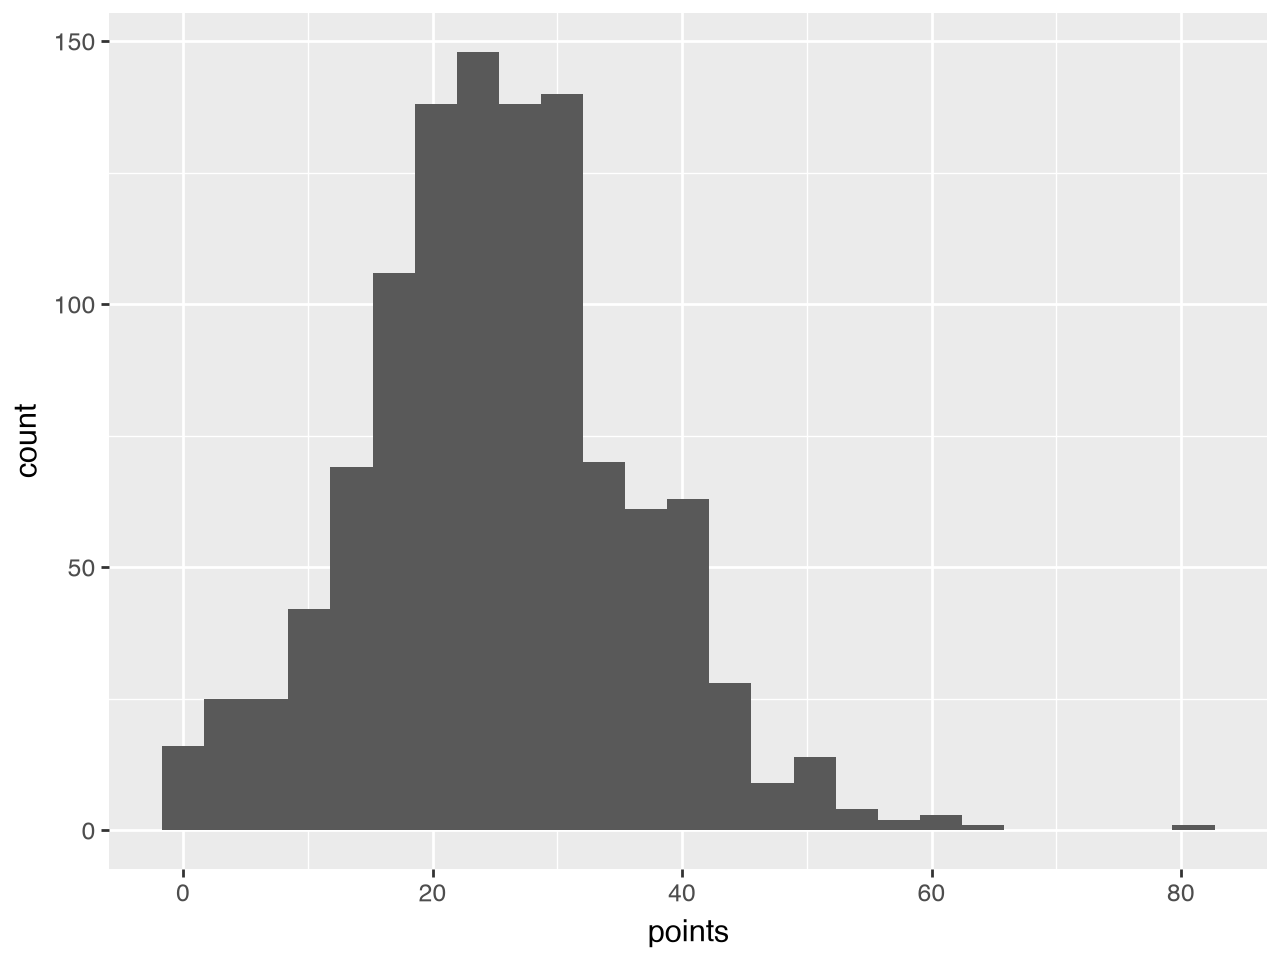

In [6]:
(ggplot(kobe, aes(x = "points"))
 + geom_histogram(bins = 25)
)


Now we can see the shape: most games are 20–35 points, a long tail of 40+, and a lump near zero (rookie-year bench minutes). **A plot answers a question that a summary number can't.**

### The type of the variable decides the plot

Before touching code, ask: *what kind of variable(s) am I plotting?* (Same definitions as last week.)

| Question involves | Plot | plotnine `geom_*` |
|---|---|---|
| one **categorical** variable | bar plot (counts) | `geom_bar` |
| one **quantitative** variable | histogram / density | `geom_histogram`, `geom_density` |
| a **quantitative** by a **categorical** | side-by-side boxplots | `geom_boxplot` |
| two **quantitative** variables | scatterplot | `geom_point` |
| a **quantitative** over **time / order** | line plot | `geom_line` |
| two **categorical** variables | stacked / dodged bars | `geom_bar` + `fill` |

Remember: `started` is stored as `0`/`1` and `season` as `1`–`15`, but they are **categorical**. The dtype does not decide — you do.


---
## 2. *How do I describe a plot to the computer?*  → the grammar of graphics: `ggplot()` + `aes()` + `geom_*()`

**Q: How many games did the Lakers win vs. lose with Kobe on the floor?**

One categorical variable (`outcome`) → a **bar plot**. Every `plotnine` plot is the *same three ingredients* added together with `+`:

1. **the data** — `ggplot(kobe, ...)`
2. **the aesthetics** — `aes(x = "outcome")`: *which column* controls *which visual element* (x position, y position, color, fill, size…)
3. **the geometry** — `geom_bar()`: *what shape* to draw

The parentheses around the whole thing let us split it across lines.


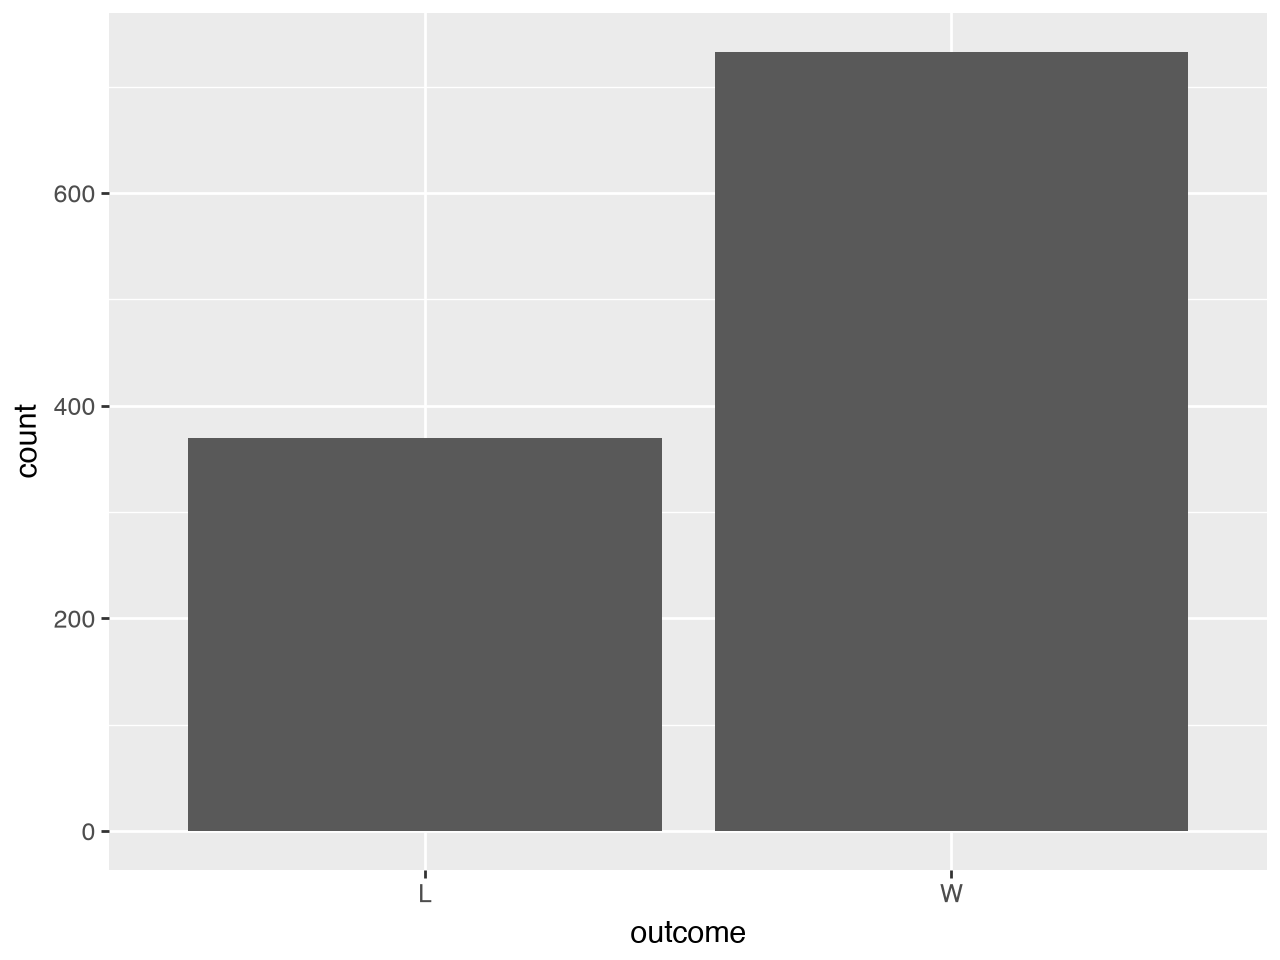

In [7]:
(ggplot(kobe, aes(x = "outcome"))     # data + aesthetic: outcome on the x-axis
 + geom_bar()                         # geometry: a bar whose height is the COUNT of rows
)


`geom_bar()` counted the rows for us — 733 wins, 370 losses. We never computed a count; the geometry did.

### Aesthetic vs. constant

**Q: Can I color the bars?** Yes — two very different ways:

| Where you put it | Meaning |
|---|---|
| inside `aes(fill = "outcome")` | *map* a **column** to fill → each level gets its own color and a legend |
| outside: `geom_bar(fill = "purple")` | *set* a **constant** → every bar is purple, no legend |


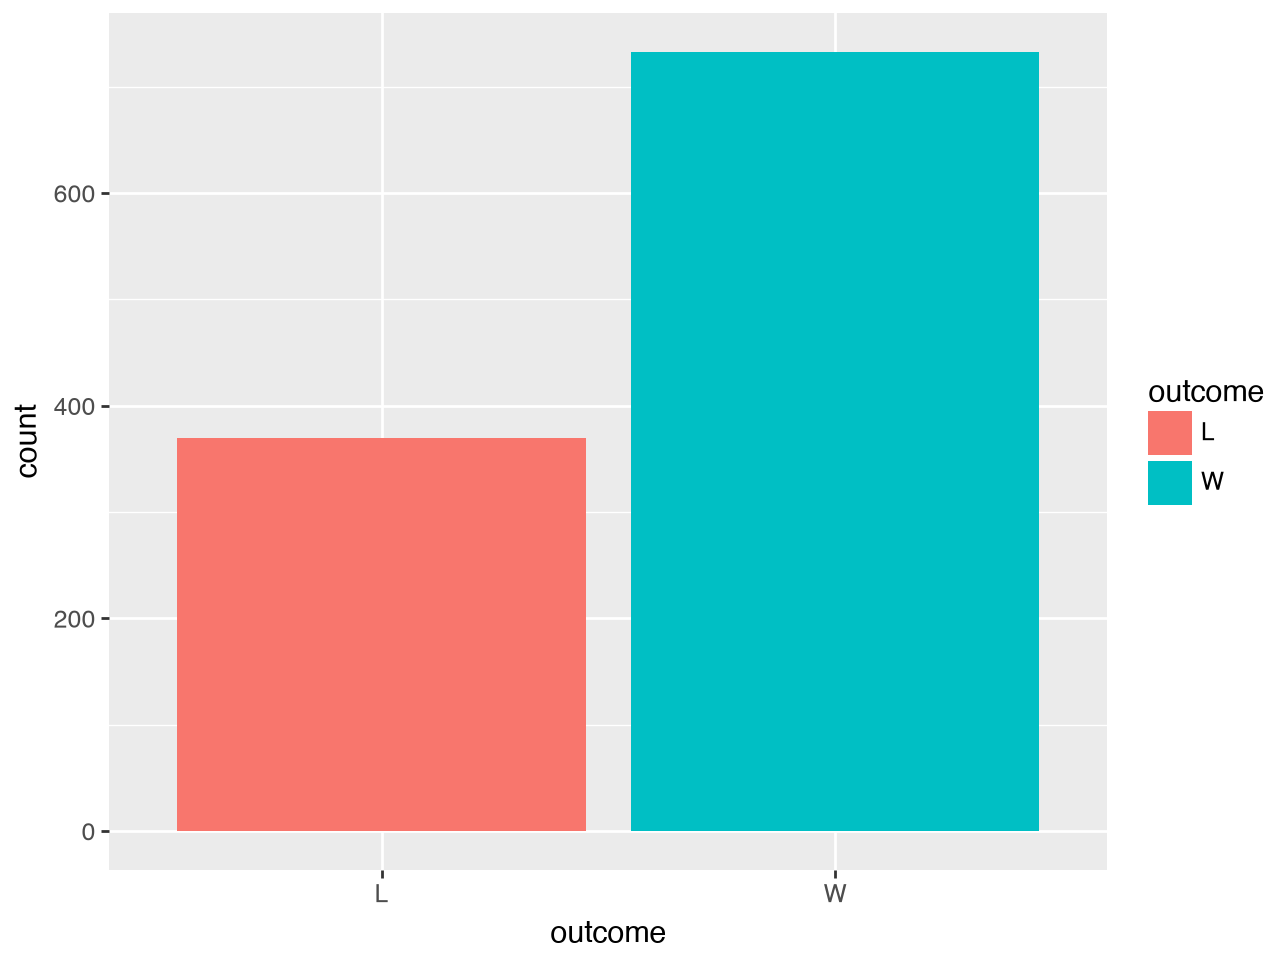

In [8]:
# fill MAPPED to a variable -> a legend appears
(ggplot(kobe, aes(x = "outcome", fill = "outcome"))
 + geom_bar()
)


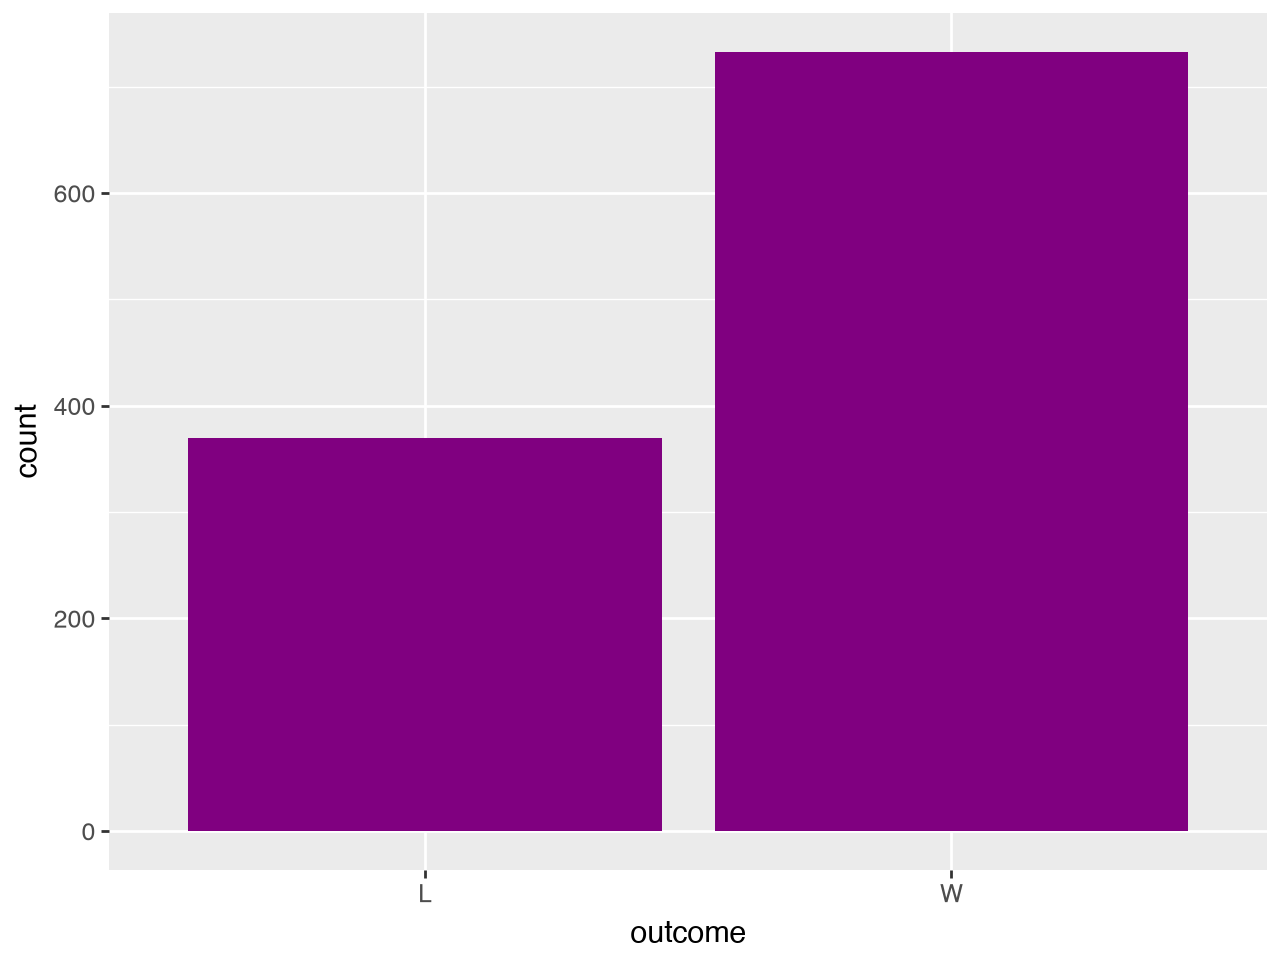

In [9]:
# fill SET to a constant -> no legend
(ggplot(kobe, aes(x = "outcome"))
 + geom_bar(fill = "purple")
)


✅ **Check:** predict what `aes(x = "outcome", fill = "purple")` does *before* running it. (Hint: `aes` treats everything inside it as data.)


In [10]:
try:
    (ggplot(kobe, aes(x = "outcome", fill = "purple")) + geom_bar()).draw()
except Exception as e:
    print(type(e).__name__, "->", e)


PlotnineError -> "Could not evaluate the 'fill' mapping: 'purple' (original error: name 'purple' is not defined)"


**Answer:** it fails. Everything inside `aes()` is read as a **column name** (or an expression using columns), so plotnine goes looking for a column called `purple` and can't find it. (In R's ggplot2 the same mistake silently draws a salmon-colored one-level legend — arguably worse.) Constants go **outside** `aes()`.


---
## 3. *Does the answer depend on a second categorical variable?*  → `fill` + `position`

**Q: Does Kobe win more at home than on the road?**

Two categorical variables (`outcome` and `location`). Put one on `x` and map the other to `fill`.


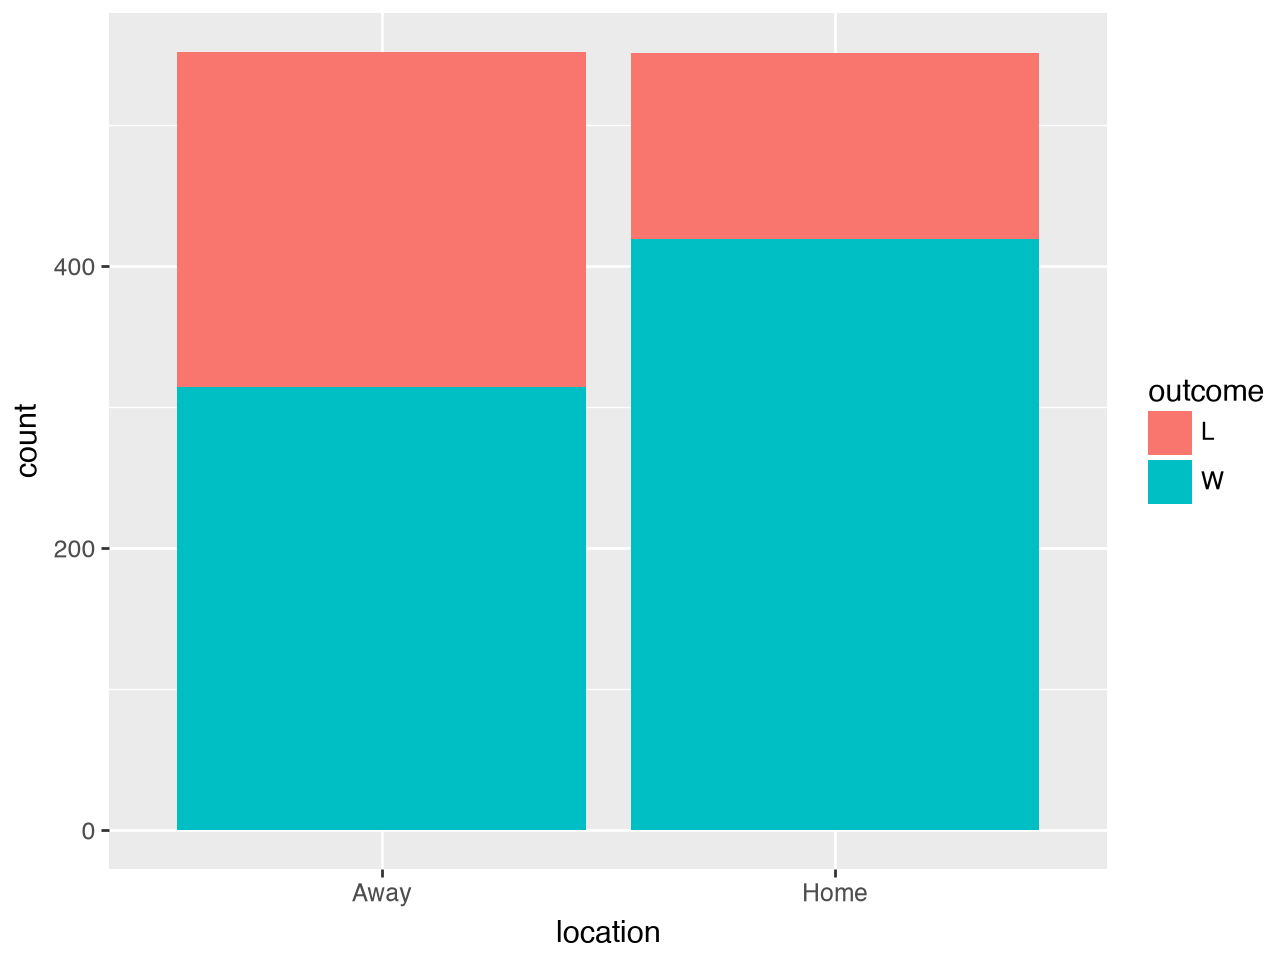

In [11]:
(ggplot(kobe, aes(x = "location", fill = "outcome"))
 + geom_bar()
)


Stacked bars show *totals* but make the win share hard to compare. `position` changes how the bars are arranged:

| `position=` | Shows |
|---|---|
| `"stack"` (default) | counts, stacked |
| `"dodge"` | counts, side by side |
| `"fill"` | **proportions** — every bar stretched to 1 |


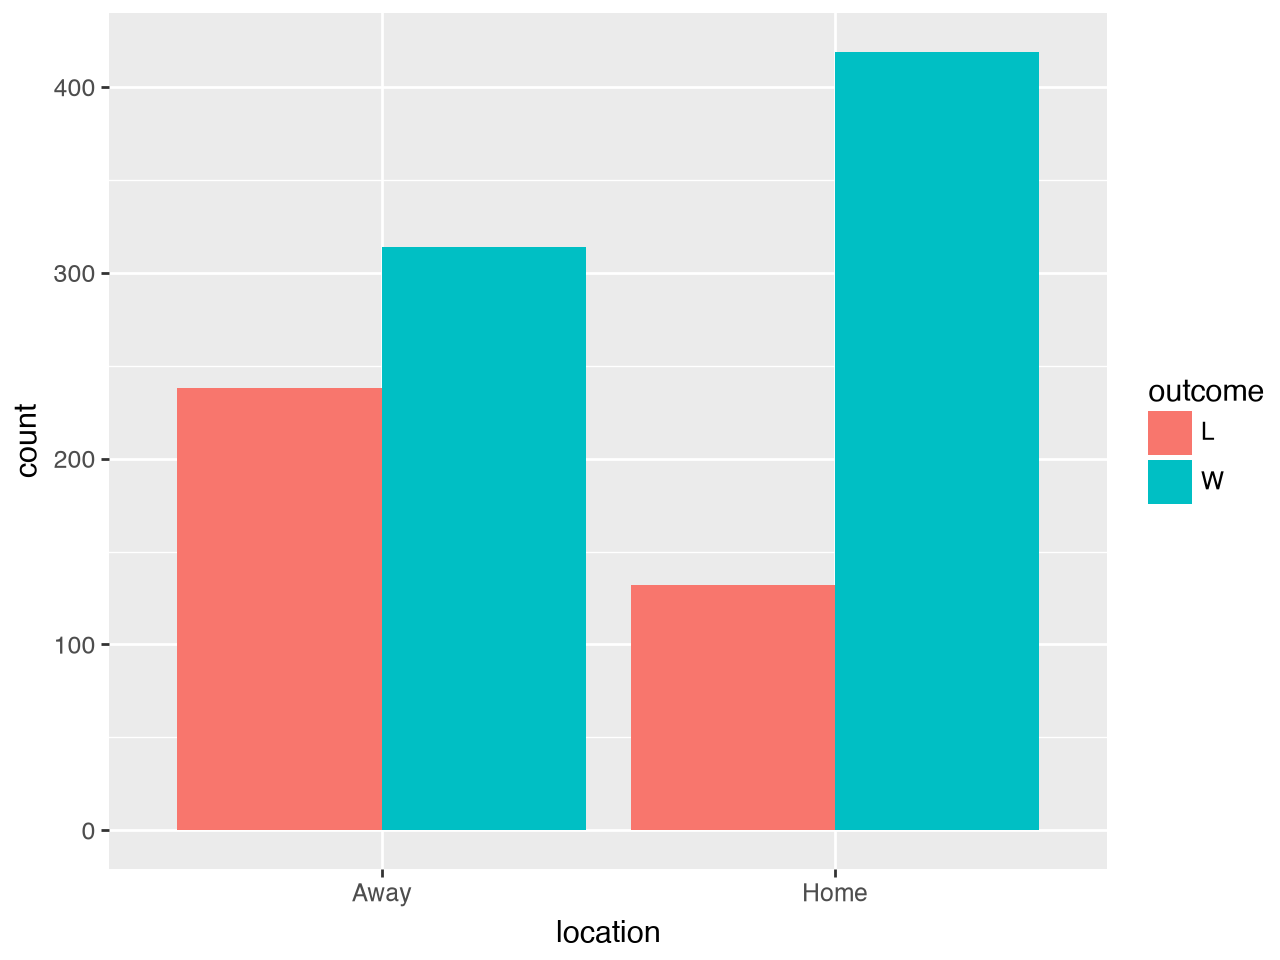

In [12]:
(ggplot(kobe, aes(x = "location", fill = "outcome"))
 + geom_bar(position = "dodge")
)


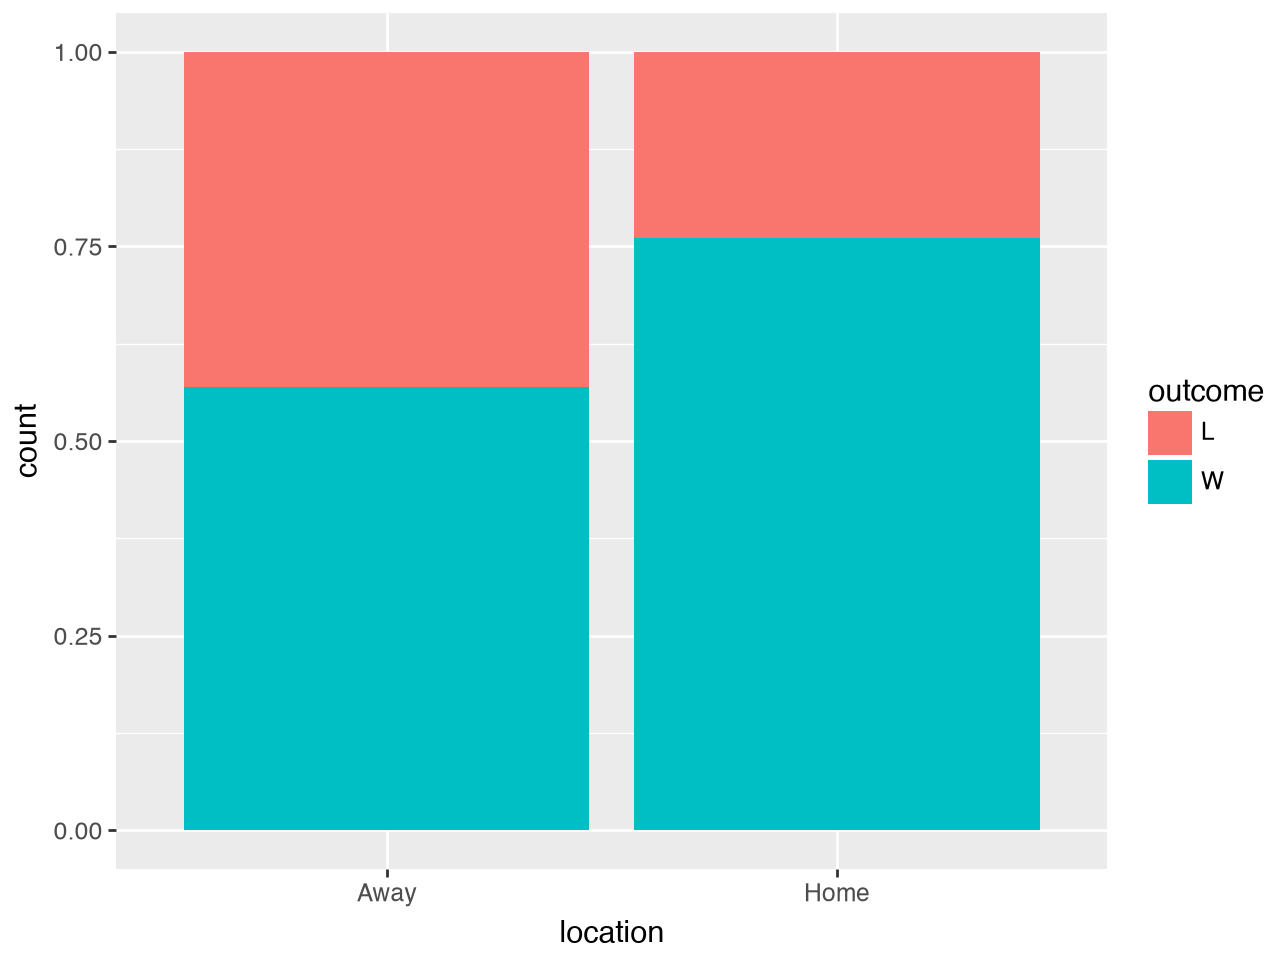

In [13]:
(ggplot(kobe, aes(x = "location", fill = "outcome"))
 + geom_bar(position = "fill")
)


The `"fill"` version answers the question directly: the win *share* is much higher at home (about 76%) than away (about 57%). Same data, three pictures — **the question decides the position.**

✅ **Check:** Is Kobe more likely to record a double-double when he *starts* than when he comes off the bench? `started` and `double_double` are numbers — the plot will treat them as quantitative unless you convert them. Convert both to `category`, then plot with `position = "fill"`.


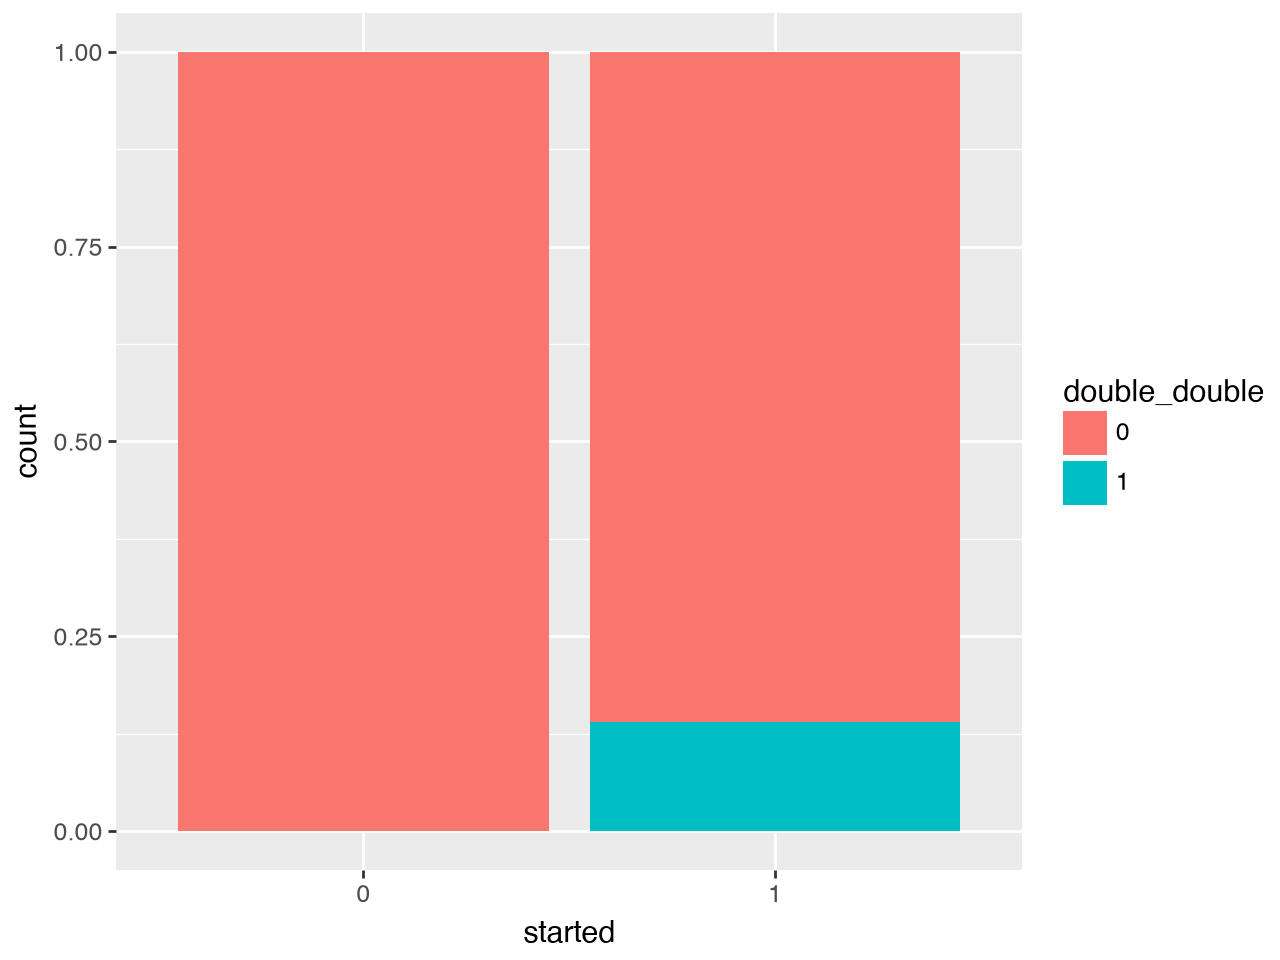

In [14]:
kobe["started"]       = kobe["started"].astype("category")
kobe["double_double"] = kobe["double_double"].astype("category")

(ggplot(kobe, aes(x = "started", fill = "double_double"))
 + geom_bar(position = "fill")
)


**Answer:** every double-double comes in a game he started (about 14% of starts, 0% of bench games) — the bench games are rookie-year cameos with few minutes. (Without `.astype("category")`, plotnine draws a numeric axis from 0 to 1 and a color *gradient* instead of two colors.)


---
## 4. *What is the shape of a quantitative variable?*  → `geom_histogram`, `geom_density`

**Q: How many minutes does Kobe play in a game?**

One quantitative variable → a **histogram**. The only decision is how many bins: too few hides the shape, too many shows noise.

*Fill in the blanks so the cell answers the question in its comment.*


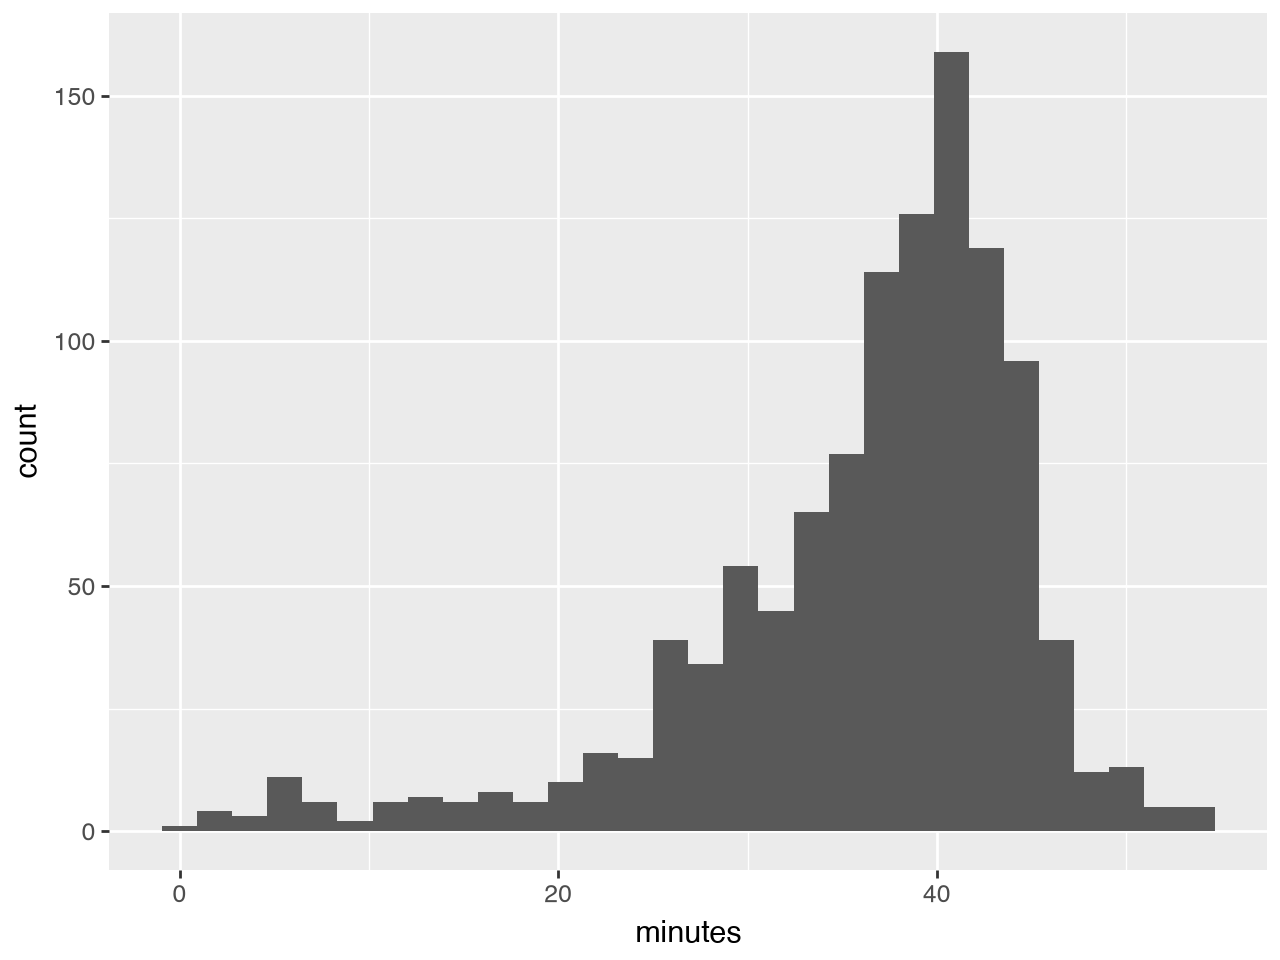

In [15]:
# Q: Minutes per game - try 10, 30, and 60 bins. Which tells the truest story?
(ggplot(kobe, aes(x = "minutes"))
 + geom_histogram(bins = 30)
)


**Q: Does his scoring distribution look different at home vs. away?**

Two overlapping histograms are hard to read. A **density** is a smoothed histogram; with `alpha` (transparency) two of them can share a plot.


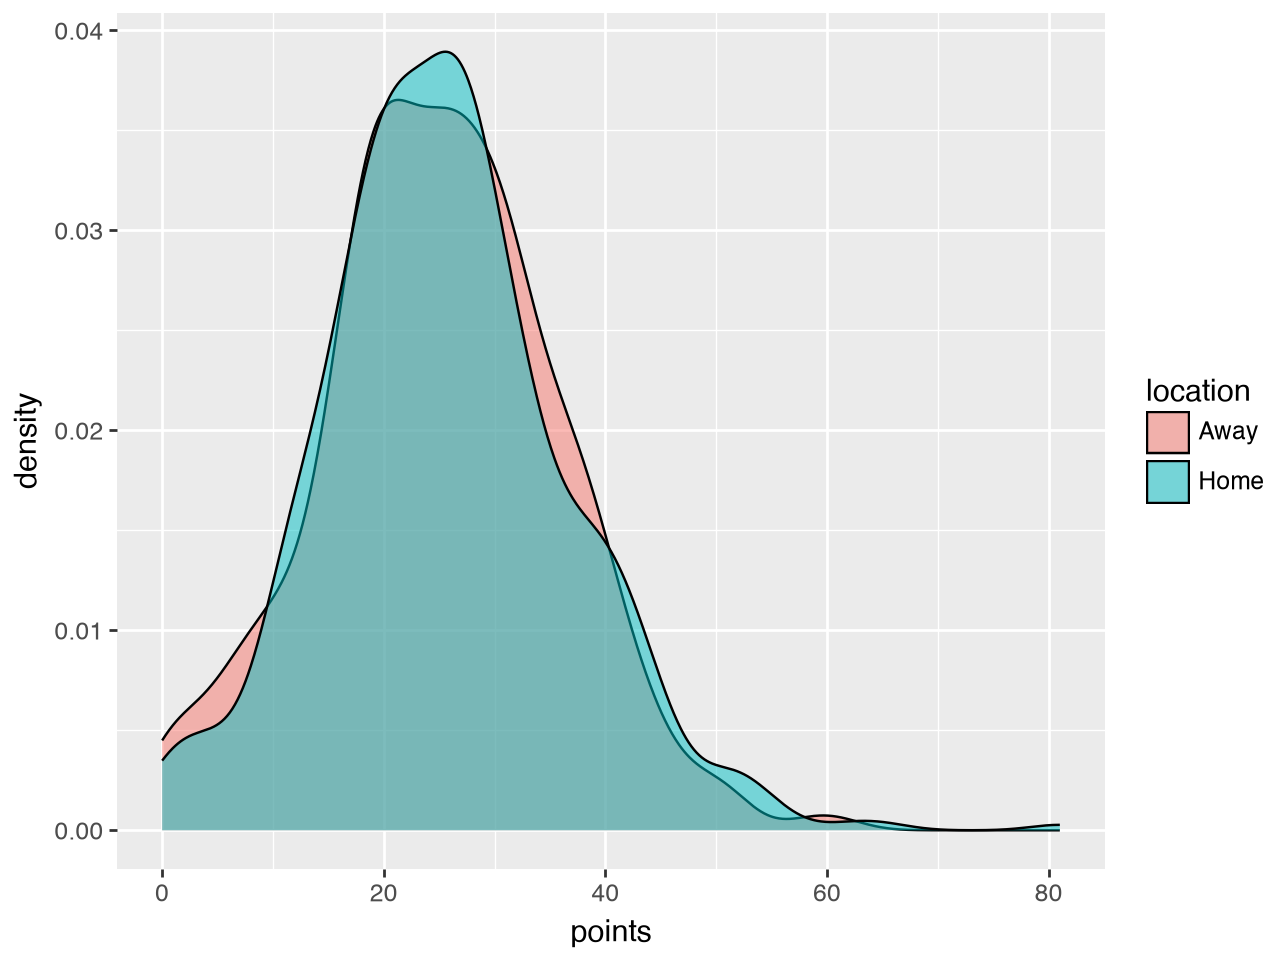

In [16]:
(ggplot(kobe, aes(x = "points", fill = "location"))
 + geom_density(alpha = 0.5)
)


The two curves sit almost on top of each other — home court barely changes *how much* he scores, even though it changes *whether they win* (Section 3).

✅ **Check:** compare the distribution of `game_score` for wins vs. losses with a density plot. Which way does it shift, and by roughly how much?


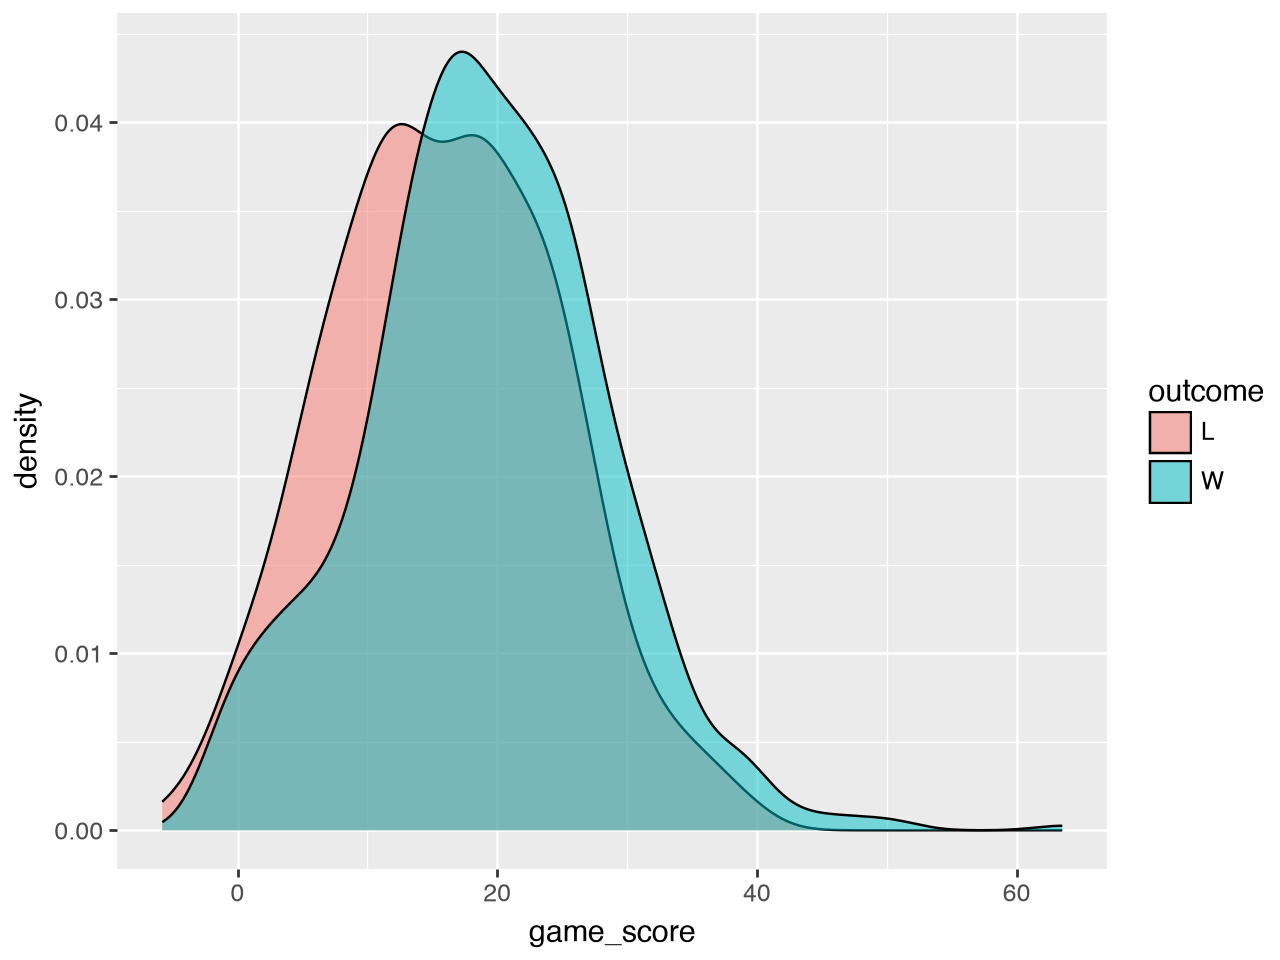

In [17]:
(ggplot(kobe, aes(x = "game_score", fill = "outcome"))
 + geom_density(alpha = 0.5)
)


**Answer:** the win curve sits to the right — Kobe's game score runs about 3 points higher in wins, though the two overlap a lot: a great Kobe game doesn't guarantee a win.


---
## 5. *How does a quantitative variable differ across groups?*  → `geom_boxplot`

**Q: Which of Kobe's seasons was his highest scoring?**

A quantitative variable (`points`) split by a categorical one (`season_label`) → **side-by-side boxplots**. Each box is one season: median line, middle-50% box, whiskers, and outlier dots.


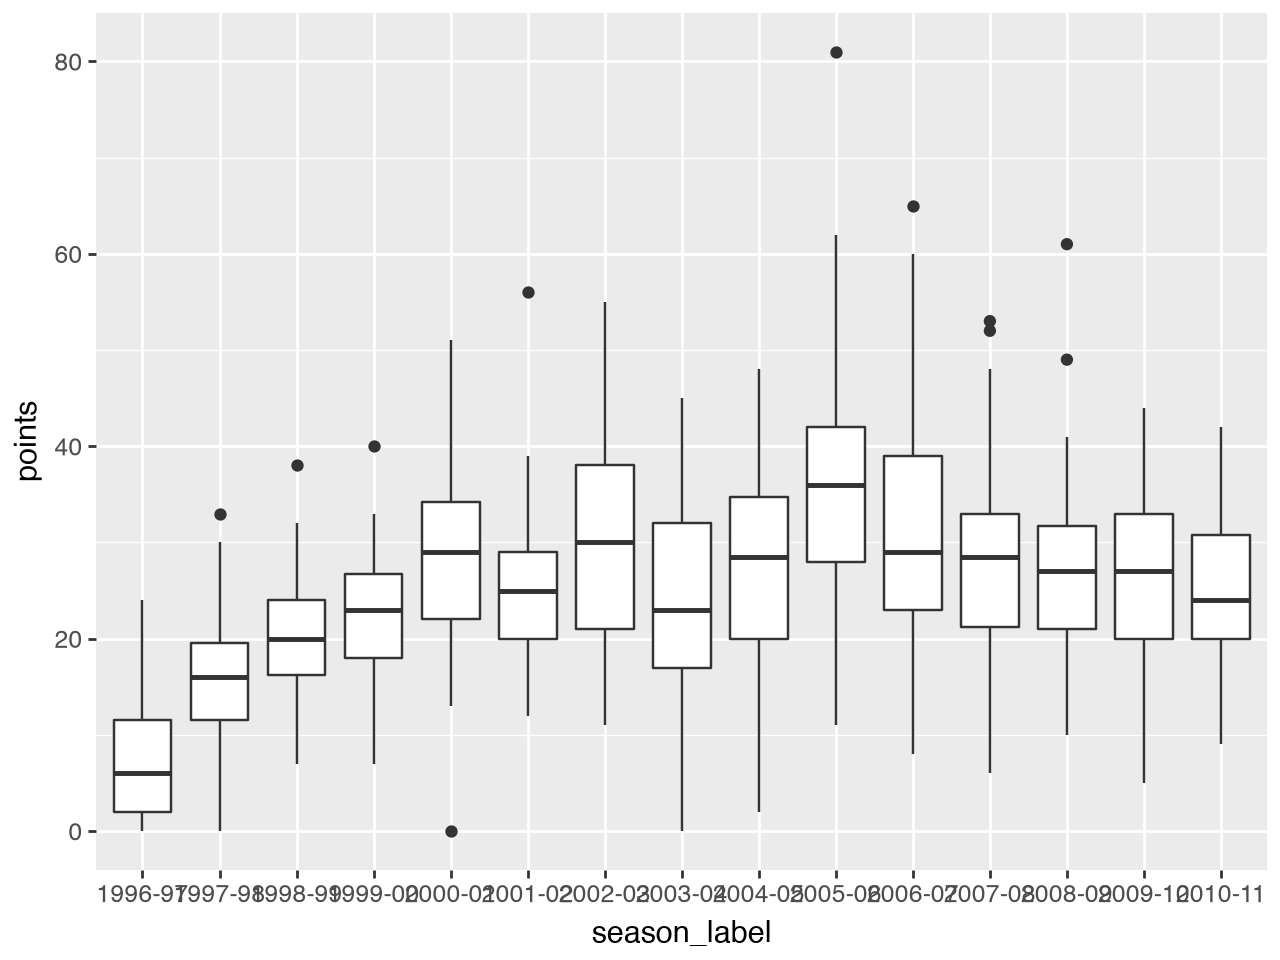

In [18]:
(ggplot(kobe, aes(x = "season_label", y = "points"))
 + geom_boxplot()
)


2005-06 stands out (median = 36 — the 81-point game is the dot at the top). But the x-axis labels are crushed together; we'll fix that in Section 8.

✅ **Check:** does Kobe score more against the Eastern or Western conference? Boxplots of `points` by `opp_conference`, and color the boxes by conference.


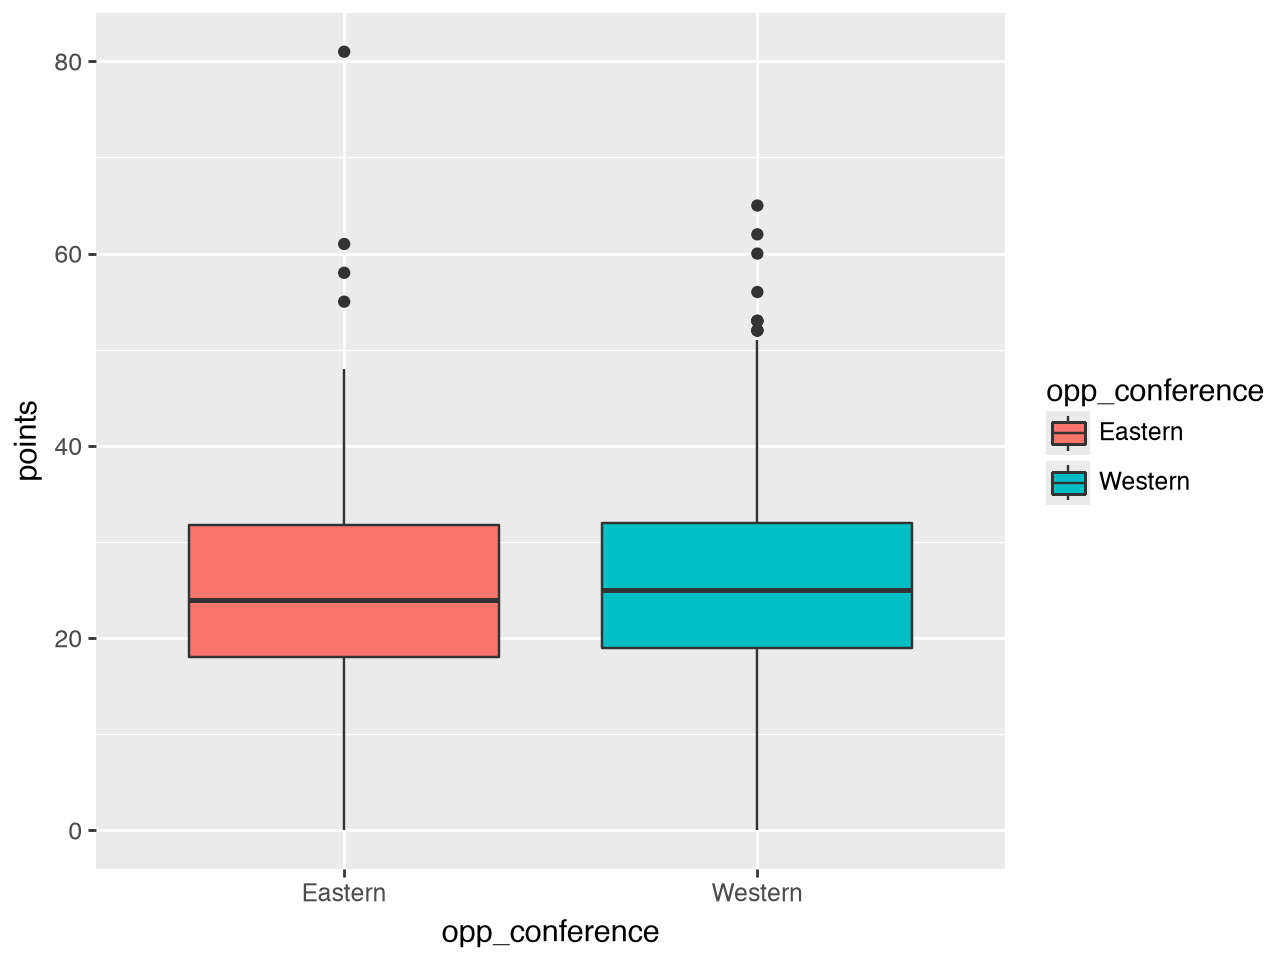

In [19]:
(ggplot(kobe, aes(x = "opp_conference", y = "points", fill = "opp_conference"))
 + geom_boxplot()
)


**Answer:** essentially no difference — the medians and boxes nearly match. (Notice that `fill = "opp_conference"` added no *information*; it just made the plot prettier. That's fine, but know the difference.)


---
## 6. *Are two quantitative variables related?*  → `geom_point`

**Q: Do more shot attempts mean more points?**

Two quantitative variables → a **scatterplot**: one dot per game.


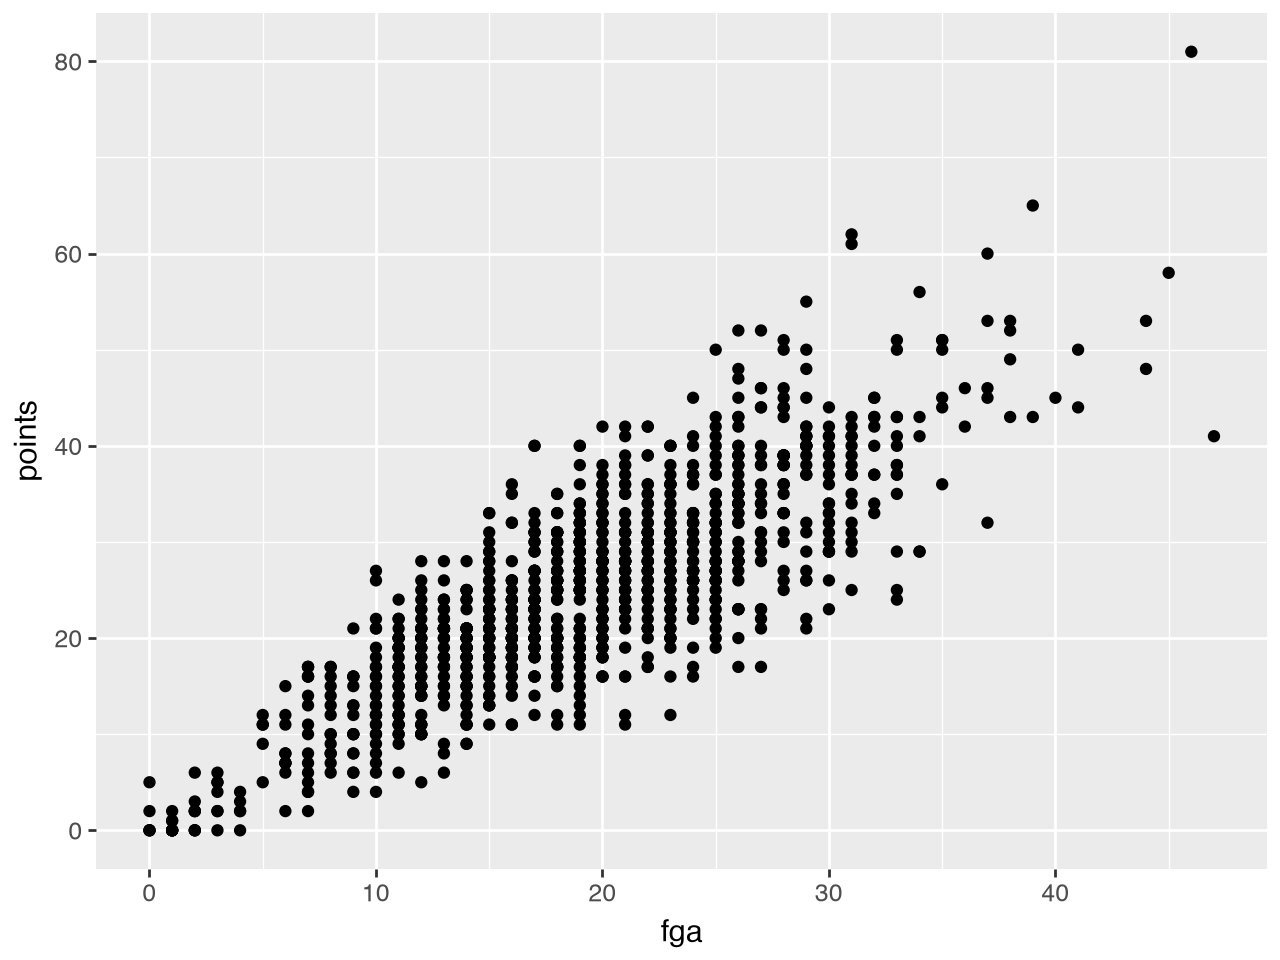

In [20]:
(ggplot(kobe, aes(x = "fga", y = "points"))
 + geom_point()
)


Strong upward trend, but wide: 25 attempts can be 20 points or 45. A third variable can ride along as `color`:


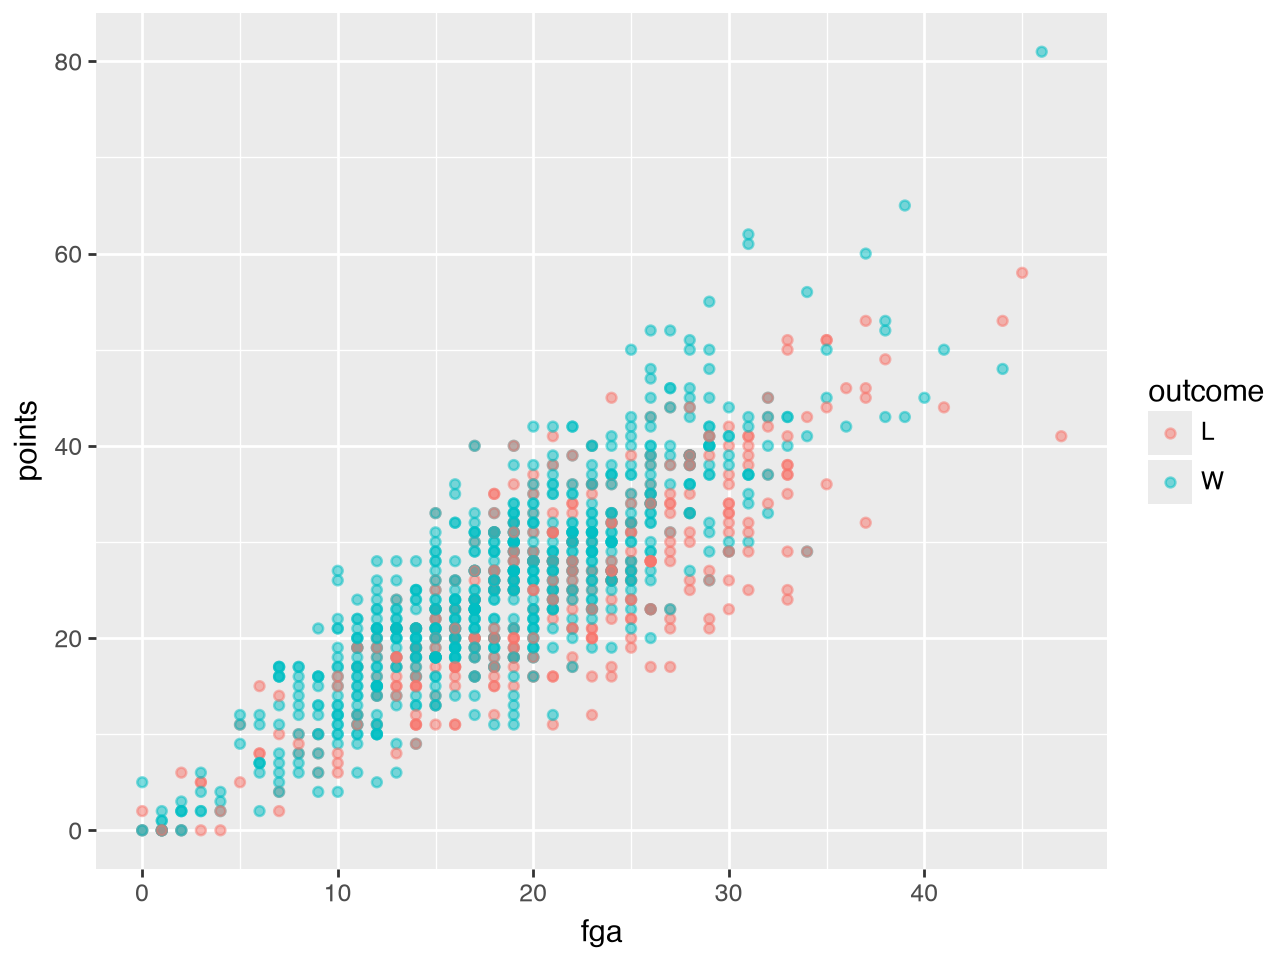

In [21]:
# Q: Are the high-attempt games more often wins or losses?
(ggplot(kobe, aes(x = "fga", y = "points", color = "outcome"))
 + geom_point(alpha = 0.5)
)


(`color` is for dots and lines; `fill` is for bars, boxes, and densities.)

✅ **Check:** is there a relationship between `assists` and `turnovers`? Many games share the exact same (assists, turnovers) pair, so the dots stack — try `geom_jitter()` instead of `geom_point()`.


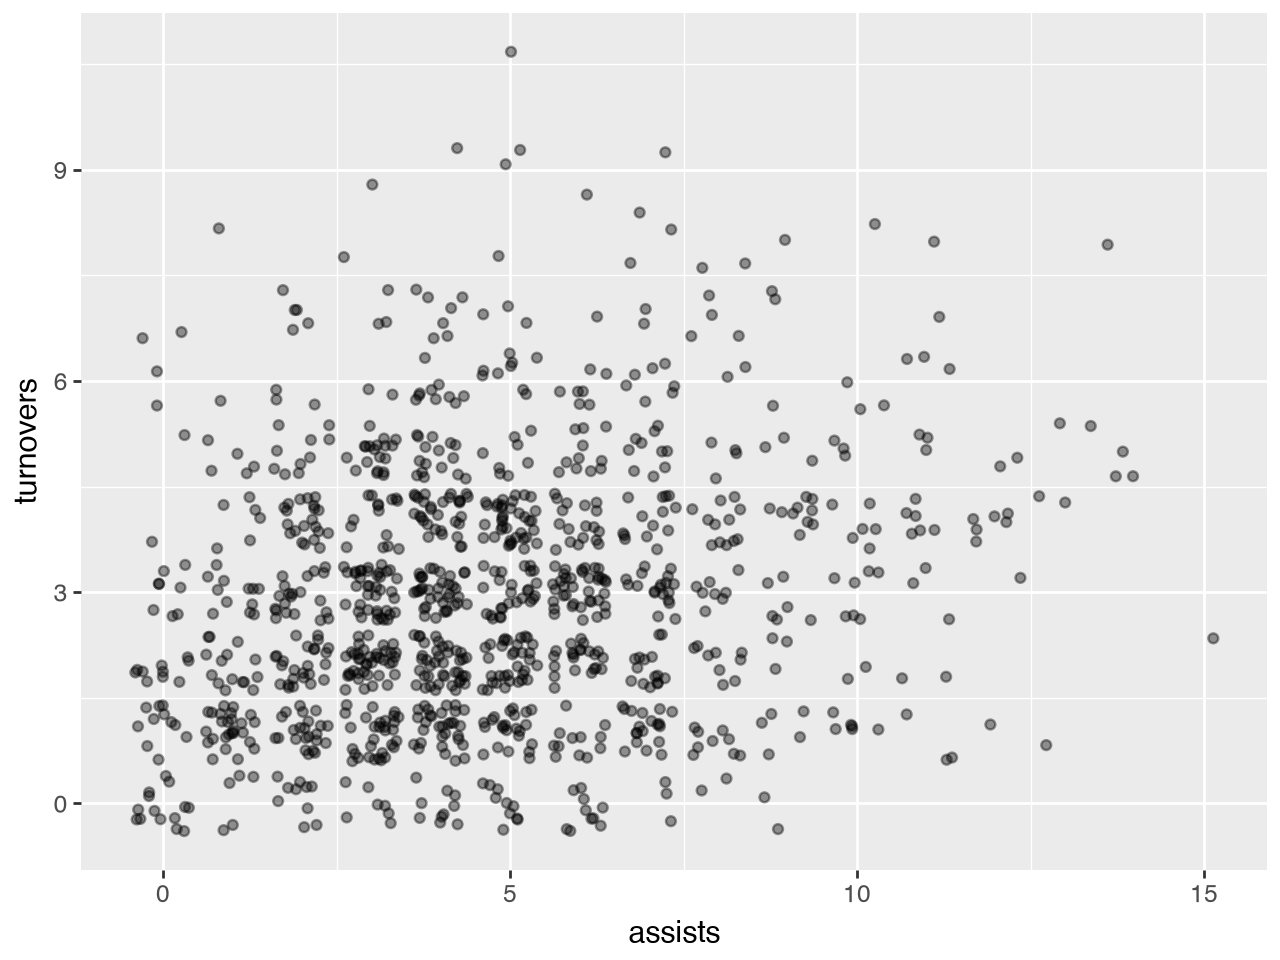

In [22]:
(ggplot(kobe, aes(x = "assists", y = "turnovers"))
 + geom_jitter(alpha = 0.4)
)


**Answer:** a weak positive relationship — games where Kobe handles the ball more have more of both. `geom_point` would show one dot per (assist, turnover) combination and hide how many games are there.


---
## 7. *How does something change over time?*  → `geom_line`

**Q: How did Kobe's scoring average change across his career?**

A line plot needs **one y-value per x-value**. We have 82 games per season, so we first *summarize* (average points per season — next week's topic, but you saw `.groupby` in the book) and then draw the line.


In [23]:
# Step 1: one row per season
by_season = kobe.groupby("season")["points"].mean().reset_index()
by_season.head()


,season,points
0,1,7.591549
1,2,15.443038
2,3,19.920000
3,4,22.500000
4,5,28.500000


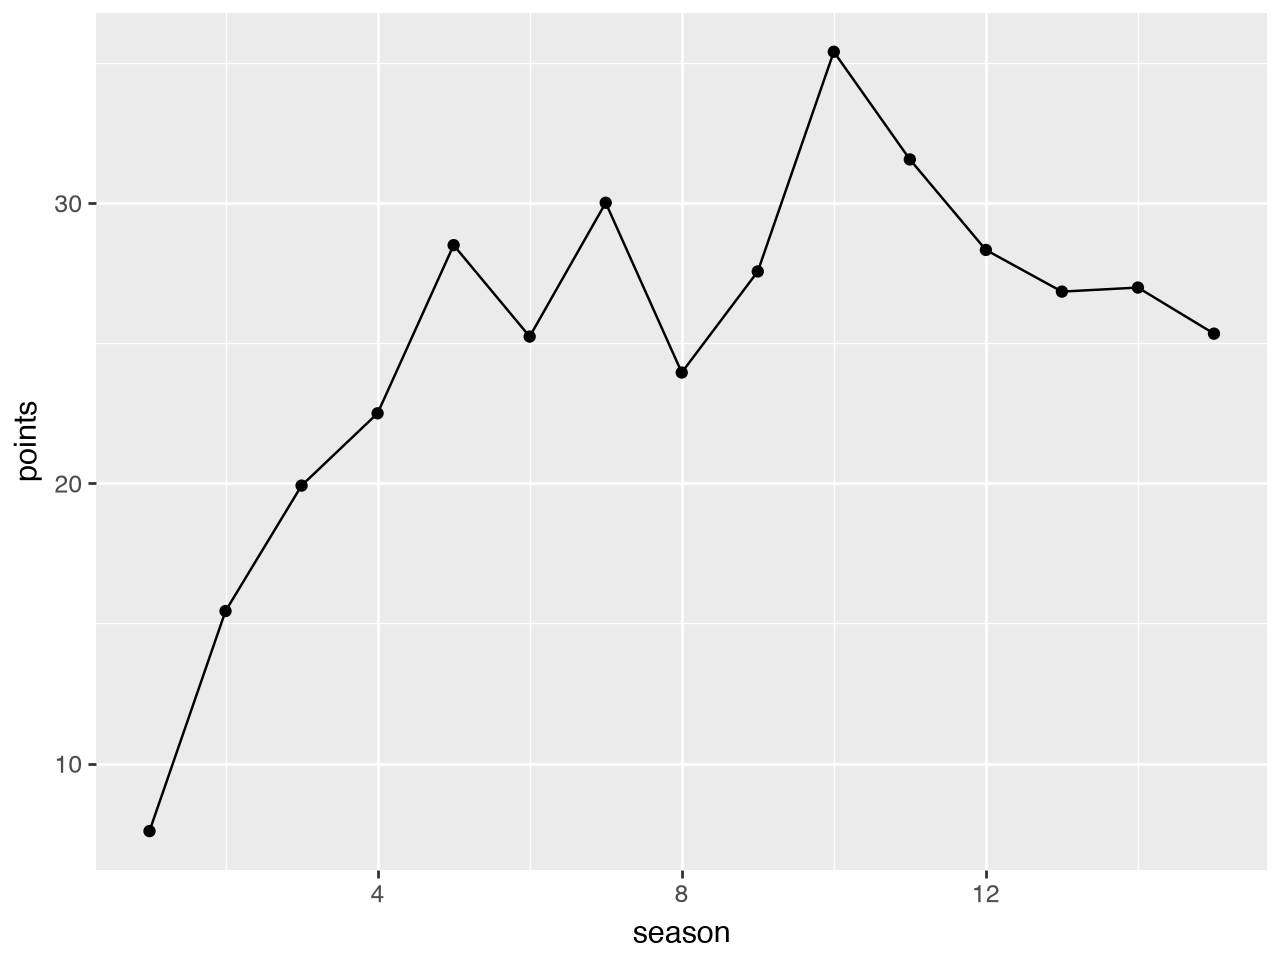

In [24]:
# Step 2: line + points   (season is numeric here, so the x-axis is in order automatically)
(ggplot(by_season, aes(x = "season", y = "points"))
 + geom_line()
 + geom_point()
)


A career arc in one picture: bench rookie, rising through 2005-06, then a slow decline.

✅ **Check:** compute the average `points` per season **separately for home and away** (`groupby(["season", "location"])`), then draw two lines with `color = "location"`. Why does `geom_line` need `color` (or `group`) here?


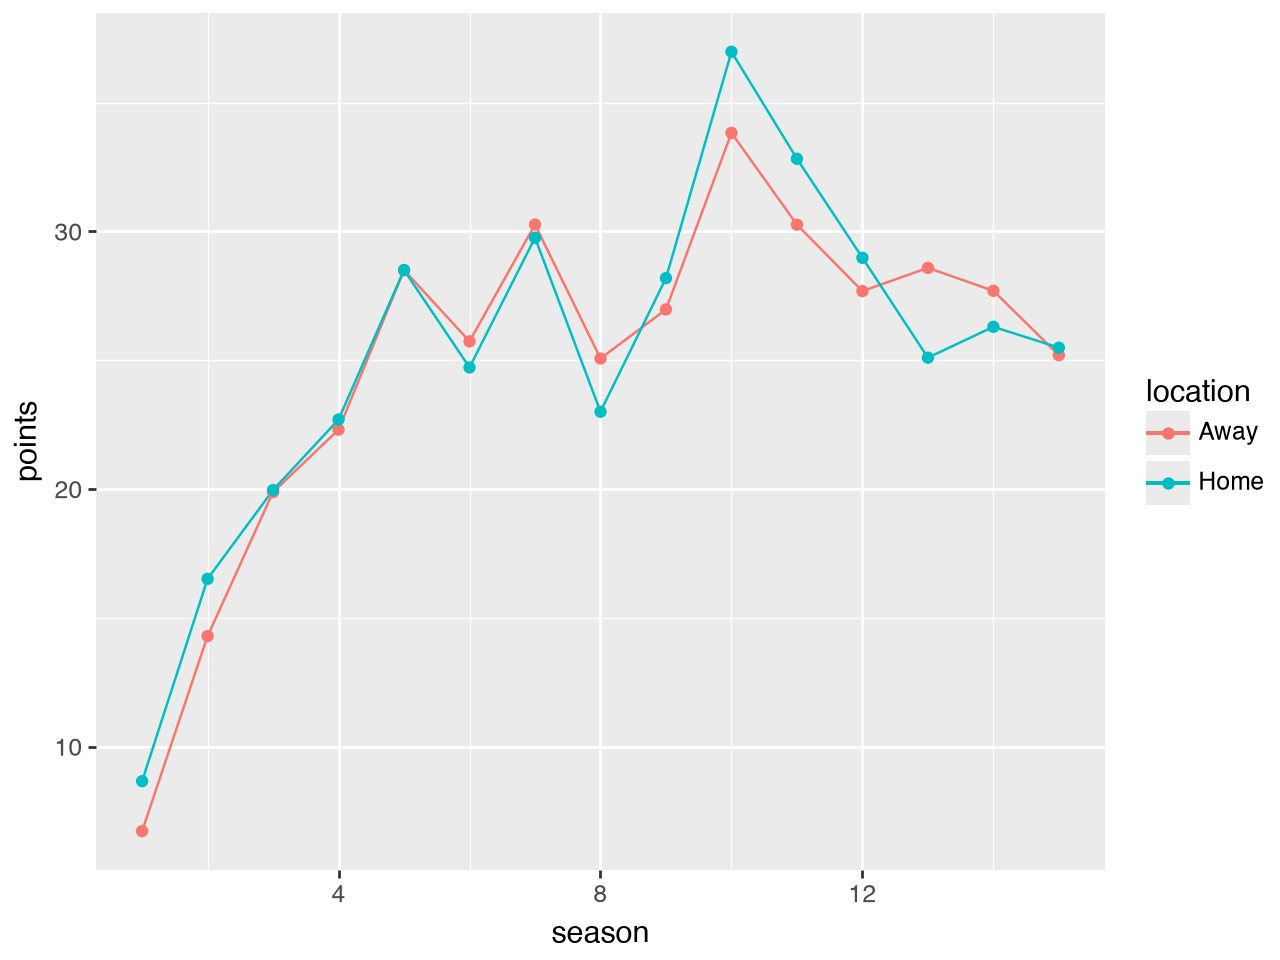

In [25]:
by_season_loc = kobe.groupby(["season", "location"])["points"].mean().reset_index()

(ggplot(by_season_loc, aes(x = "season", y = "points", color = "location"))
 + geom_line()
 + geom_point()
)


**Answer:** without `color`/`group`, `geom_line` would connect *all* the dots into one zig-zag line. Mapping `location` tells it there are two series to draw.


---
## 8. *How do I make the plot presentable?*  → `labs()`, `scale_*`, `theme_*`

Everything so far answered the question *for us*. To show it to someone else we need labels, sensible axes, and a clean look. These are extra layers — just keep adding with `+`.

| Layer | Controls |
|---|---|
| `labs(title=, x=, y=, fill=, color=)` | text on the plot |
| `scale_x_continuous(breaks=...)`, `scale_y_reverse()`, `scale_x_log10()` | how a **numeric** axis is drawn |
| `scale_fill_manual(values=[...])`, `scale_color_manual(...)` | which colors the levels get |
| `theme_minimal()`, `theme_classic()`, `theme_bw()` | overall look |
| `theme(axis_text_x = element_text(angle = 45, hjust = 1))` | one specific element |

Start from the Section 5 boxplot and fix the crushed labels:


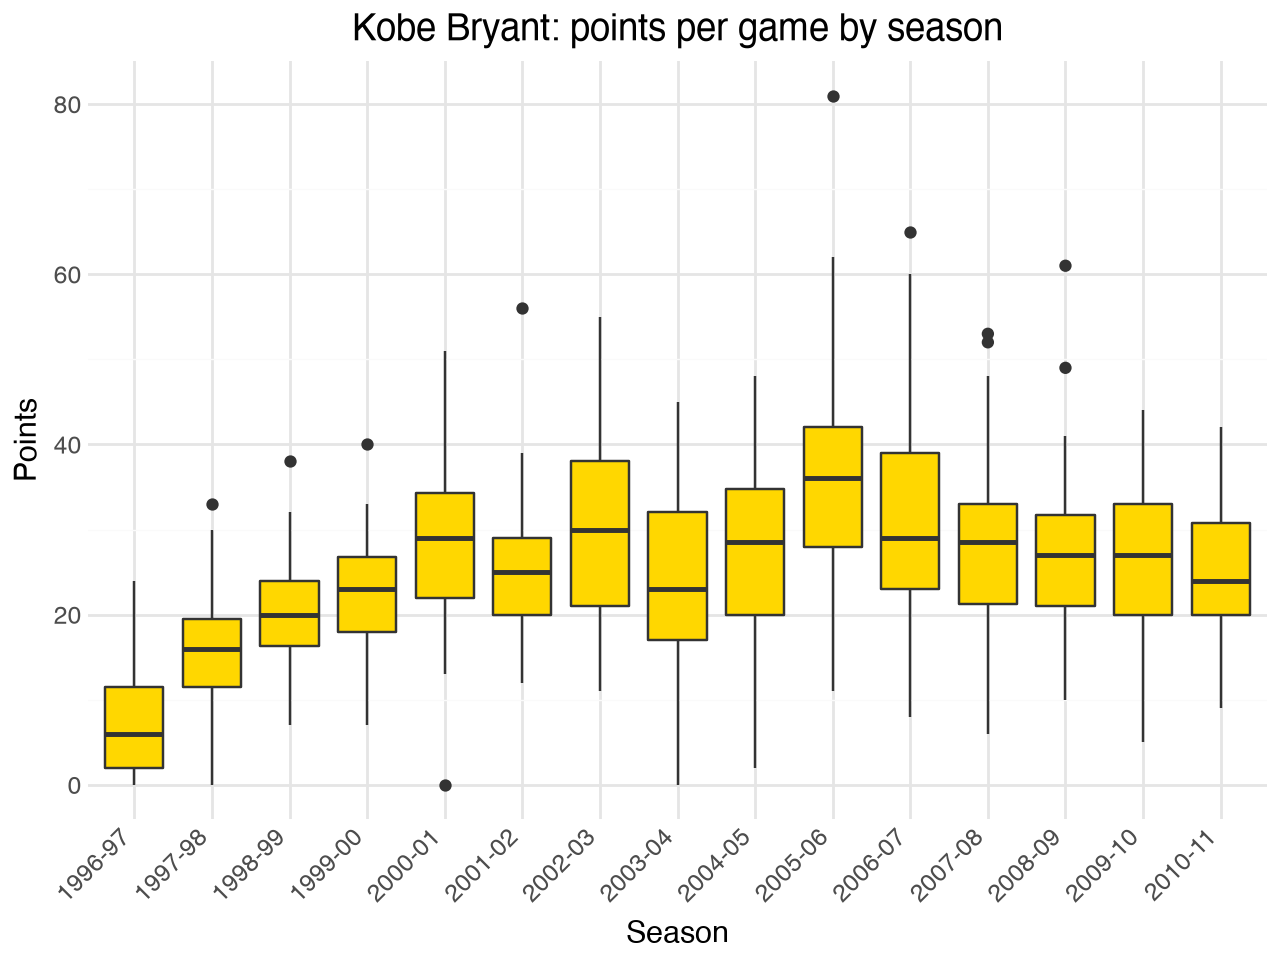

In [26]:
(ggplot(kobe, aes(x = "season_label", y = "points"))
 + geom_boxplot(fill = "gold")
 + labs(title = "Kobe Bryant: points per game by season",
        x = "Season", y = "Points")
 + theme_minimal()
 + theme(axis_text_x = element_text(angle = 45, hjust = 1))
)


Now the career-average line with honest axis ticks and Lakers colors:


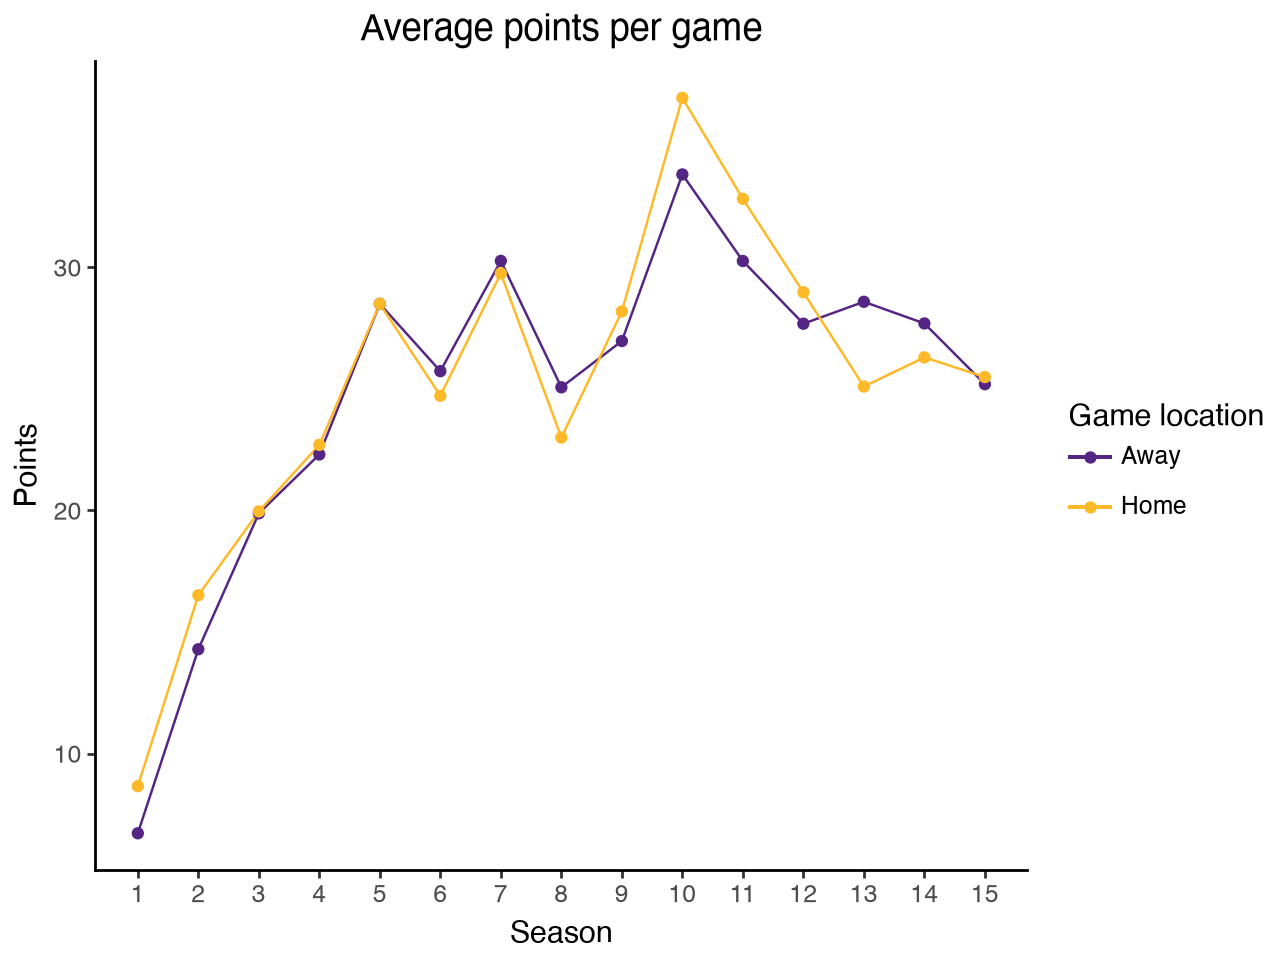

In [27]:
(ggplot(by_season_loc, aes(x = "season", y = "points", color = "location"))
 + geom_line()
 + geom_point()
 + scale_x_continuous(breaks = range(1, 16))                 # a tick at every season
 + scale_color_manual(values = ["#552583", "#FDB927"])        # Lakers purple & gold
 + labs(title = "Average points per game", x = "Season", y = "Points", color = "Game location")
 + theme_classic()
)


✅ **Check:** take the `position = "fill"` bar plot from Section 3 and (a) label the y-axis "Share of games", (b) title it, (c) color wins gold and losses purple, (d) use `theme_bw()`.


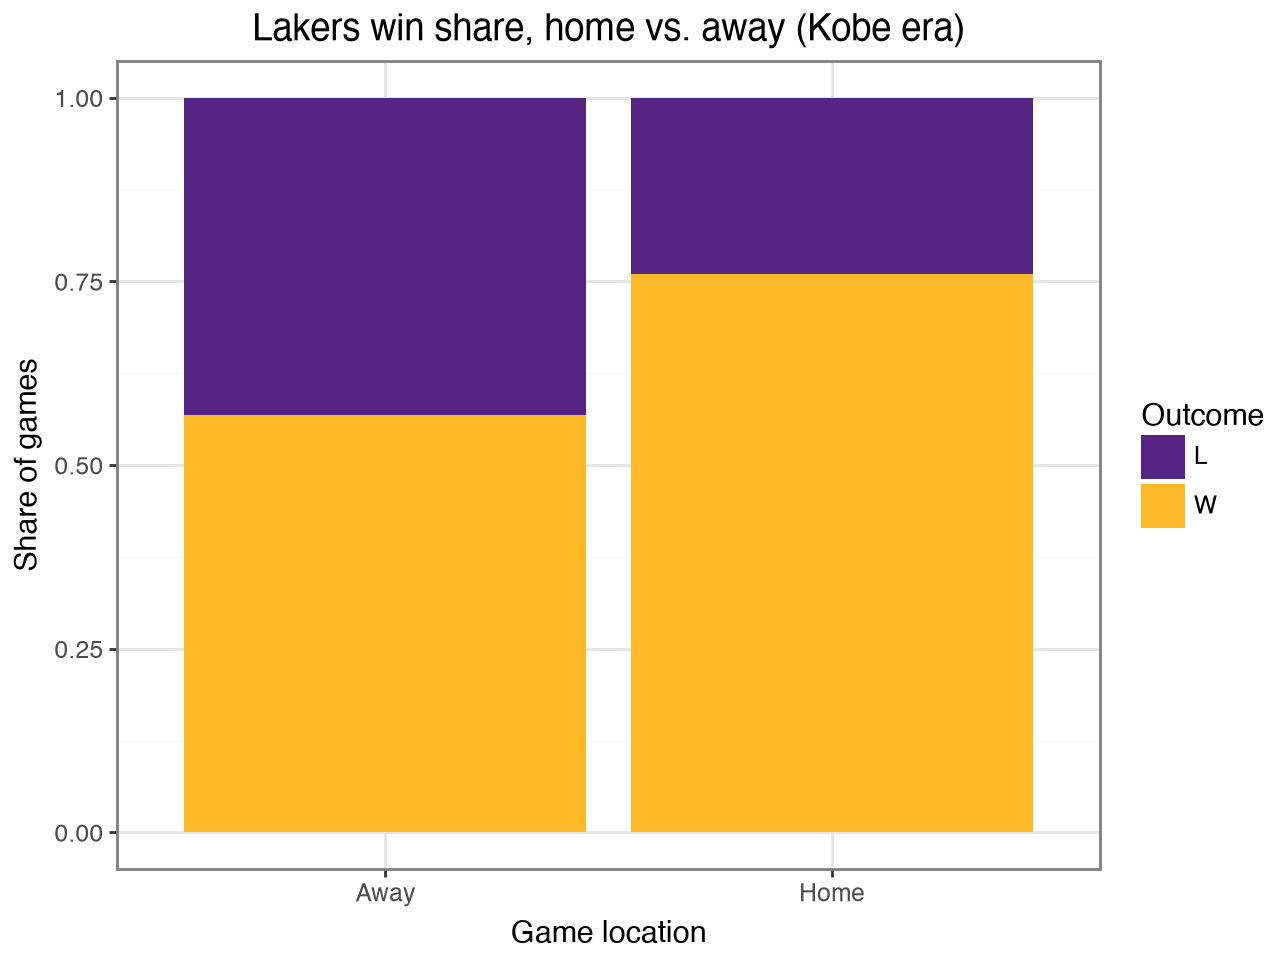

In [28]:
(ggplot(kobe, aes(x = "location", fill = "outcome"))
 + geom_bar(position = "fill")
 + scale_fill_manual(values = ["#552583", "#FDB927"])
 + labs(title = "Lakers win share, home vs. away (Kobe era)",
        x = "Game location", y = "Share of games", fill = "Outcome")
 + theme_bw()
)


---
## 9. *Does the pattern hold within every group?*  → `facet_wrap()`

**Q: Does the shots→points relationship look the same in wins and losses?**

Color (Section 6) put both groups on one panel. `facet_wrap("variable")` draws **one panel per level** — same axes, so panels compare directly.


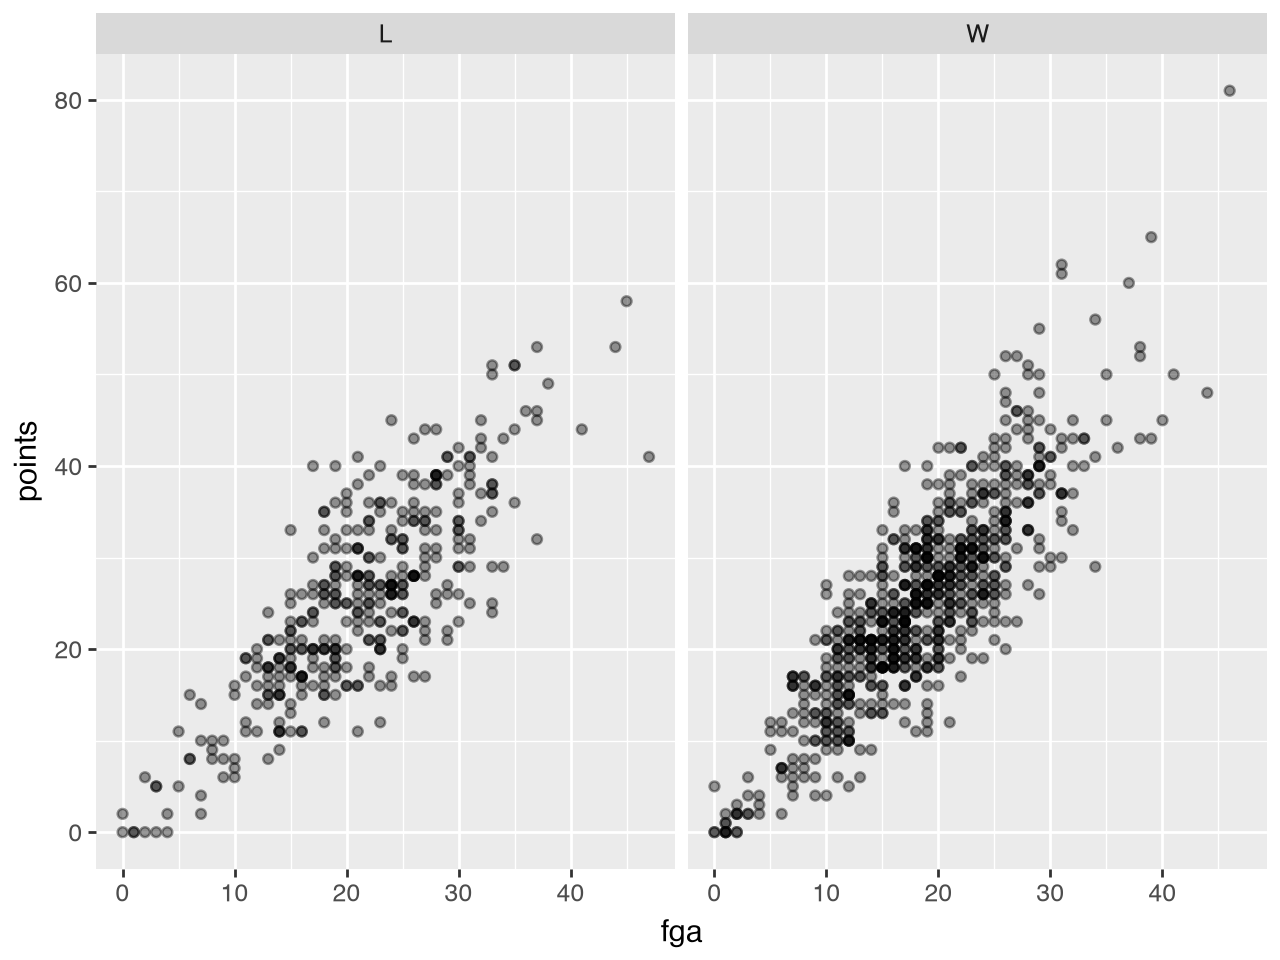

In [29]:
(ggplot(kobe, aes(x = "fga", y = "points"))
 + geom_point(alpha = 0.4)
 + facet_wrap("outcome")
)


Same slope in both panels — a loss is not "Kobe shooting worse", there are just fewer of them. Facets can take a second variable too:


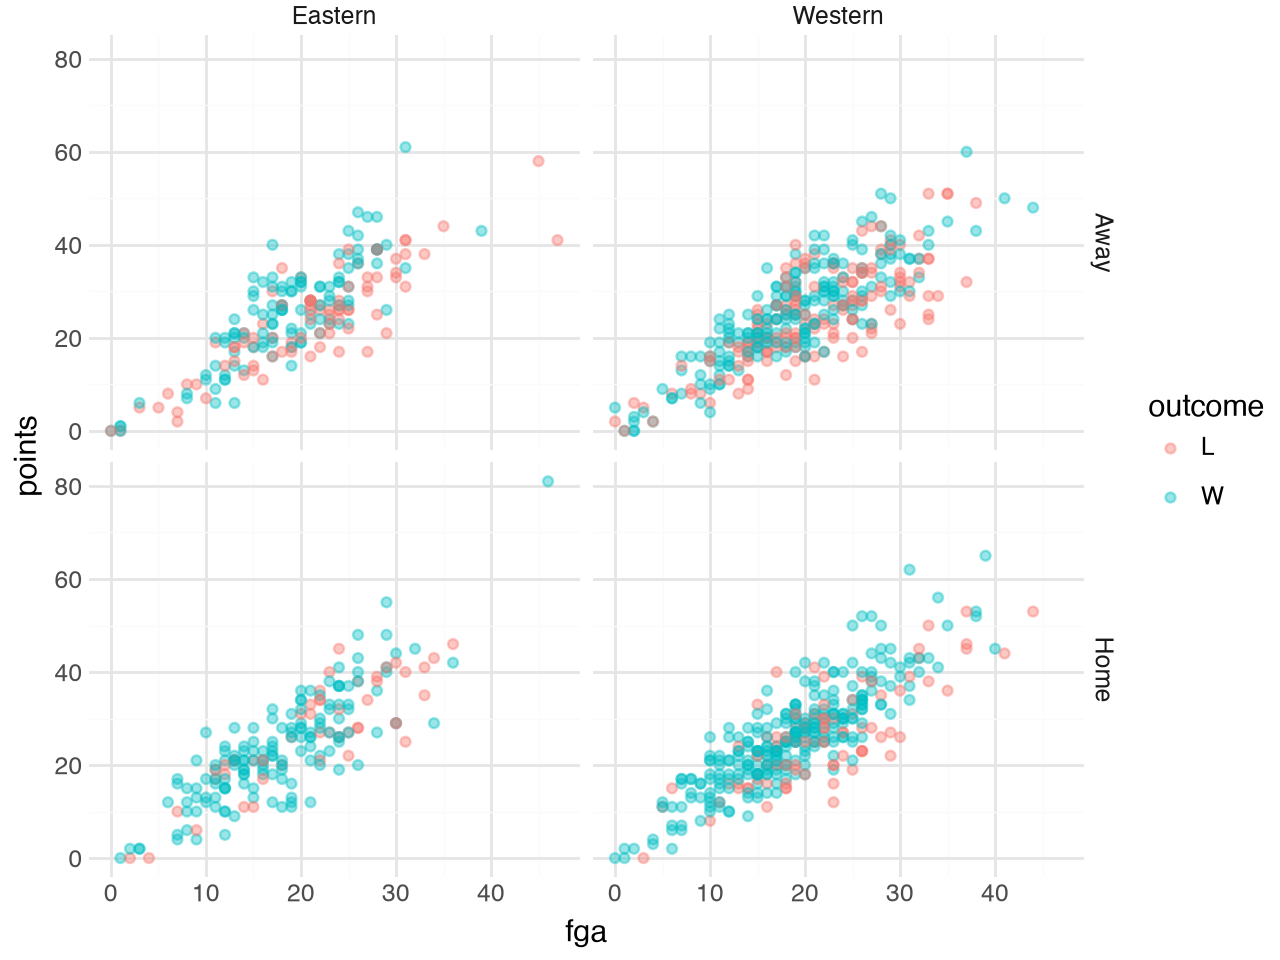

In [30]:
# Q: ...and does it hold across home/away AND conference?   (rows: location, columns: conference)
(ggplot(kobe, aes(x = "fga", y = "points", color = "outcome"))
 + geom_point(alpha = 0.4)
 + facet_grid("location ~ opp_conference")
 + theme_minimal()
)


✅ **Check:** the Section 4 density of `points` by `location` was hard to read for a single season. Draw `geom_density(alpha = 0.5)` of `points` filled by `location`, faceted by `season_label`. Which seasons show a real home/away gap?


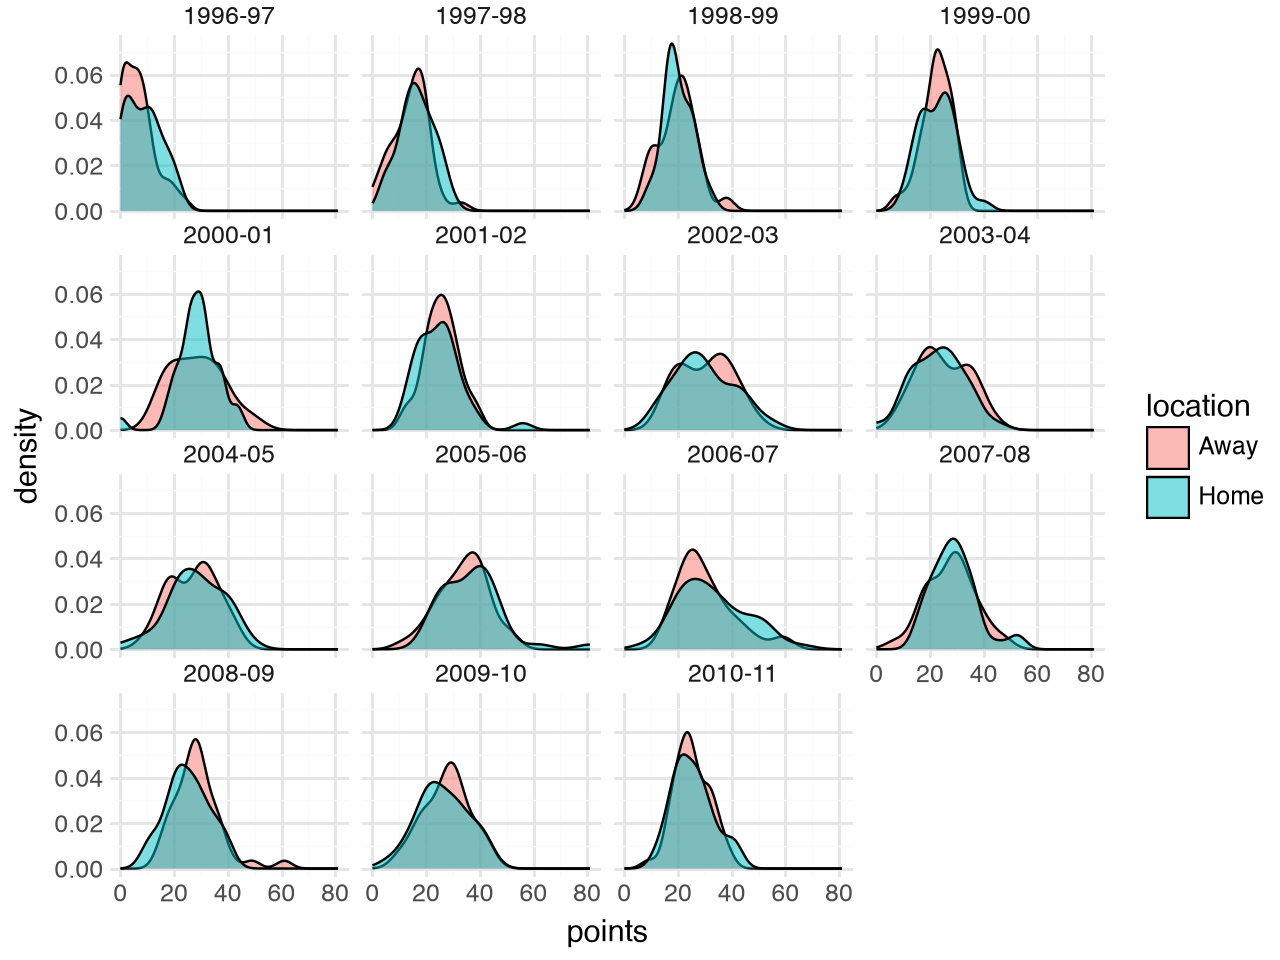

In [31]:
(ggplot(kobe, aes(x = "points", fill = "location"))
 + geom_density(alpha = 0.5)
 + facet_wrap("season_label")
 + theme_minimal()
)


**Answer:** most seasons overlap almost completely; 2005-06 and 2006-07 show a higher home curve, and 2008-09 goes the other way. Facets make "is this pattern general?" a question you can *see*.


---
## 10. Practice Activities — you pick the plot

For each question: (1) name the variable types, (2) pick the geometry from the table in Section 1, (3) build the plot, (4) answer in one sentence. Solutions will be posted after class.

**PA 1.** How many games did Kobe play against each conference, and how did they split into wins and losses?


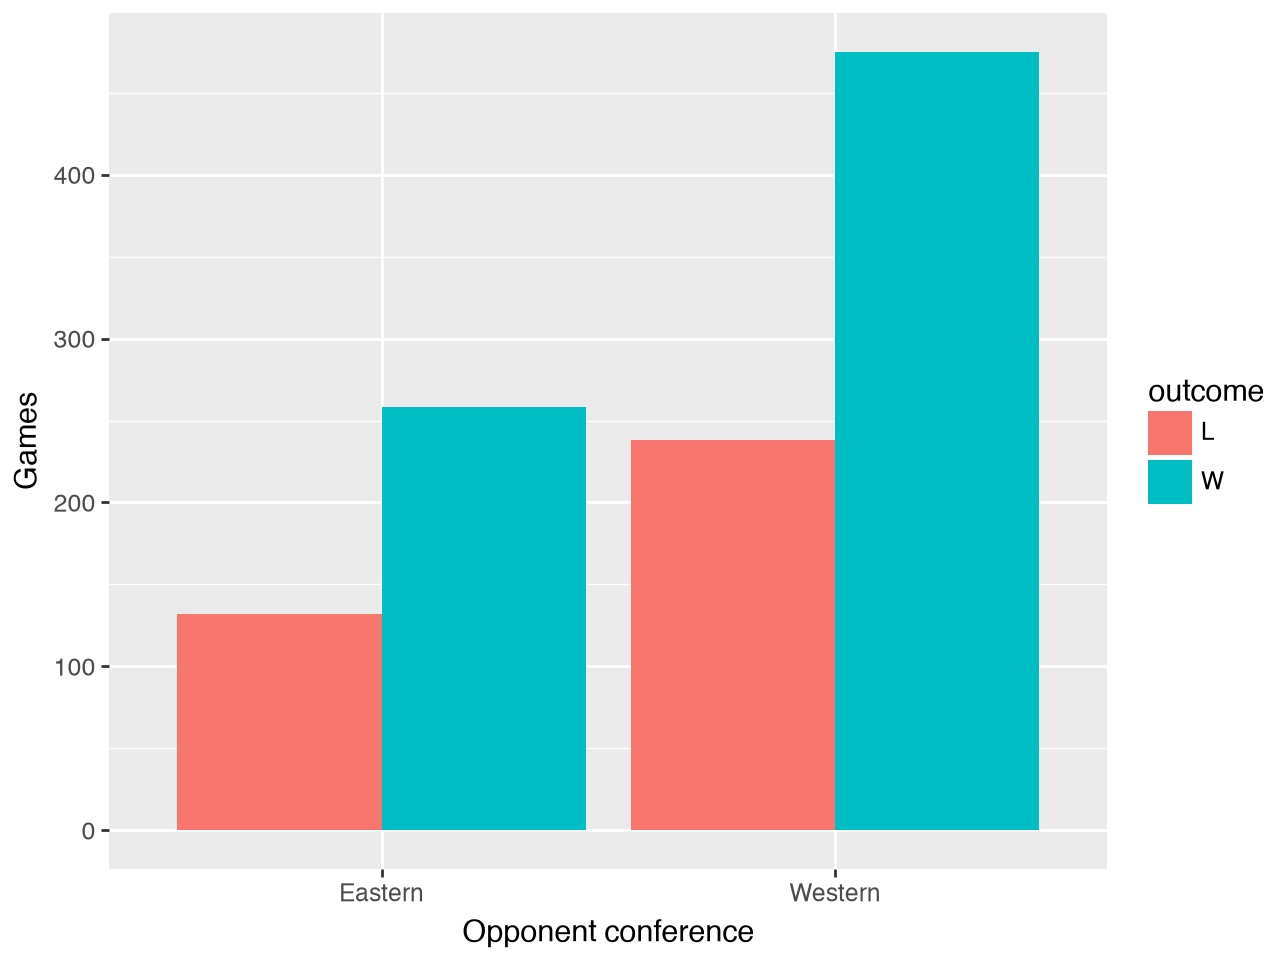

In [32]:
# Categorical x categorical -> bar plot with fill
(ggplot(kobe, aes(x = "opp_conference", fill = "outcome"))
 + geom_bar(position = "dodge")
 + labs(x = "Opponent conference", y = "Games")
)


**Answer:** far more Western games (the Lakers play their own conference more often); the win/loss split is similar in both.

**PA 2.** How does the distribution of `minutes` compare between games Kobe started and games he came off the bench?


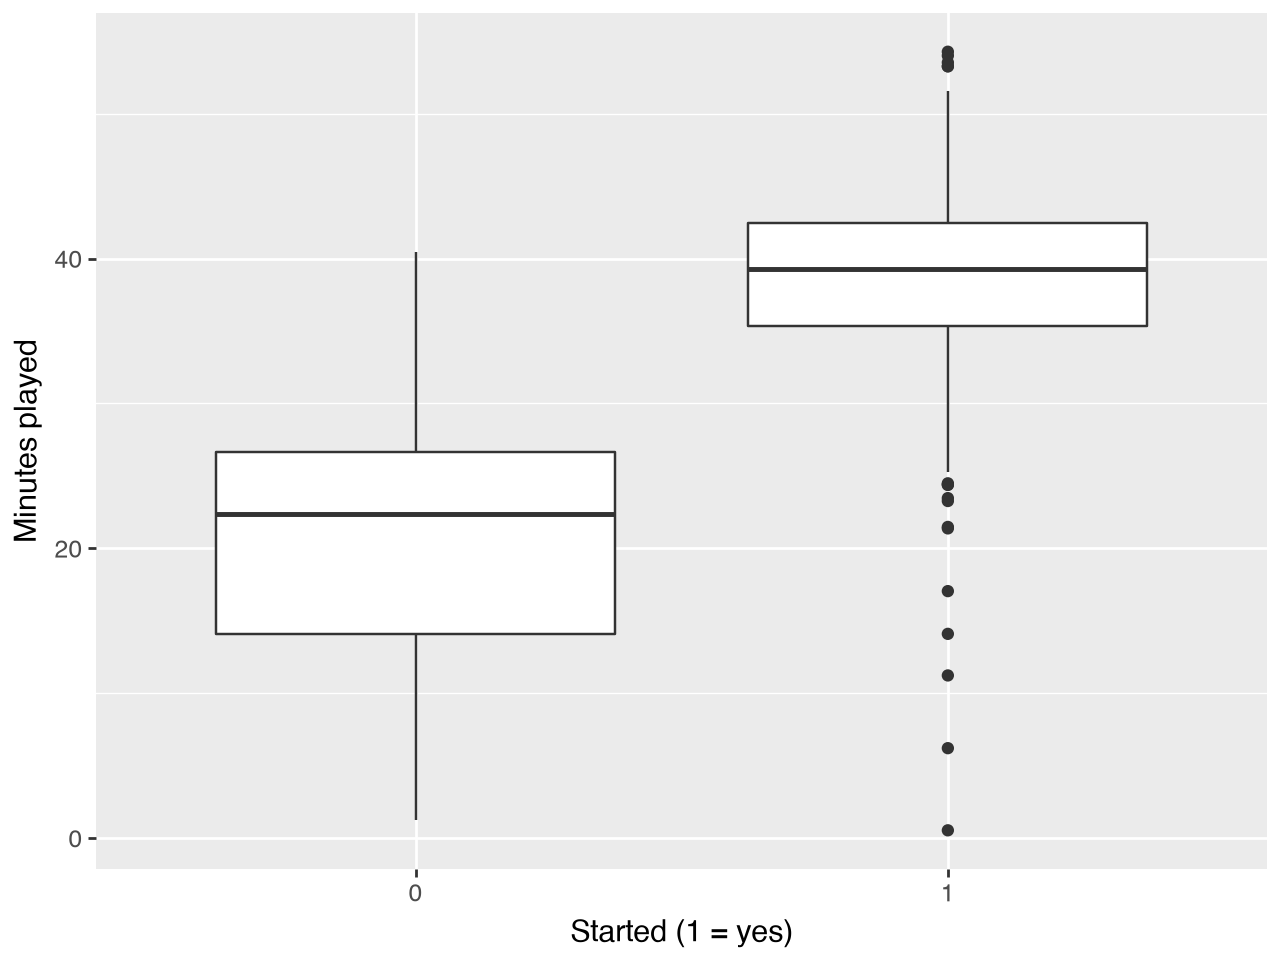

In [33]:
# Quantitative by categorical -> boxplots (or densities)
(ggplot(kobe, aes(x = "started", y = "minutes"))
 + geom_boxplot()
 + labs(x = "Started (1 = yes)", y = "Minutes played")
)


**Answer:** starts are 35–45 minutes; bench games are mostly 10–30, with much more spread.

**PA 3.** Is there a relationship between `point_margin` (how much the Lakers won or lost by) and Kobe's `game_score`? Color by `outcome`. Does anything about the colors look "too obvious", and why?


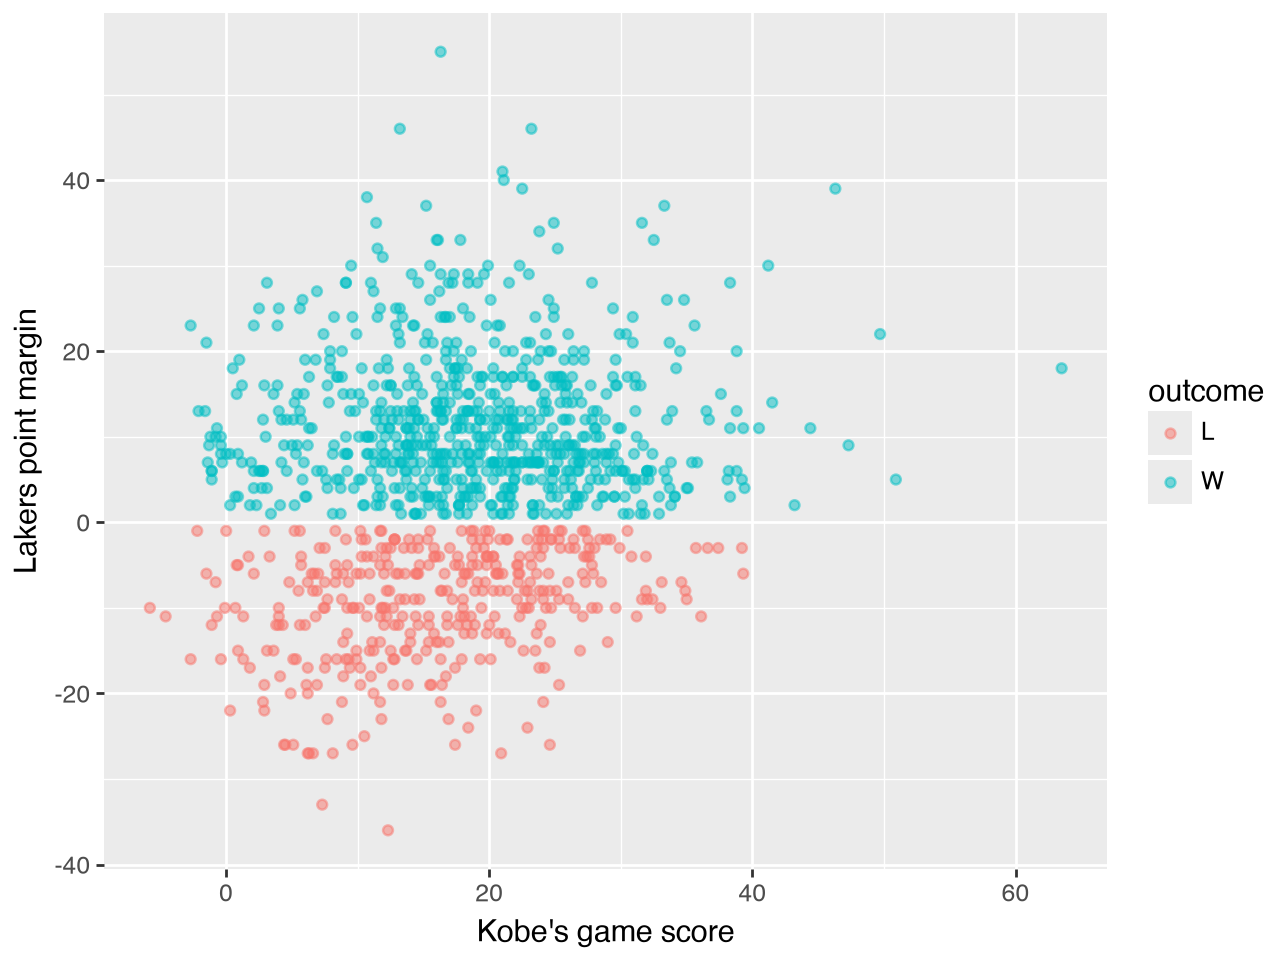

In [34]:
(ggplot(kobe, aes(x = "game_score", y = "point_margin", color = "outcome"))
 + geom_point(alpha = 0.5)
 + labs(x = "Kobe's game score", y = "Lakers point margin")
)


**Answer:** a weak positive relationship (a great Kobe game is only loosely tied to the margin). The colors split *exactly* at margin = 0 because `outcome` is **defined by** `point_margin` — the color adds nothing the y-axis didn't already say.

**PA 4.** How did Kobe's average `fg_pct` change over his career? Draw one line per `location`, label the axes, and use a theme.


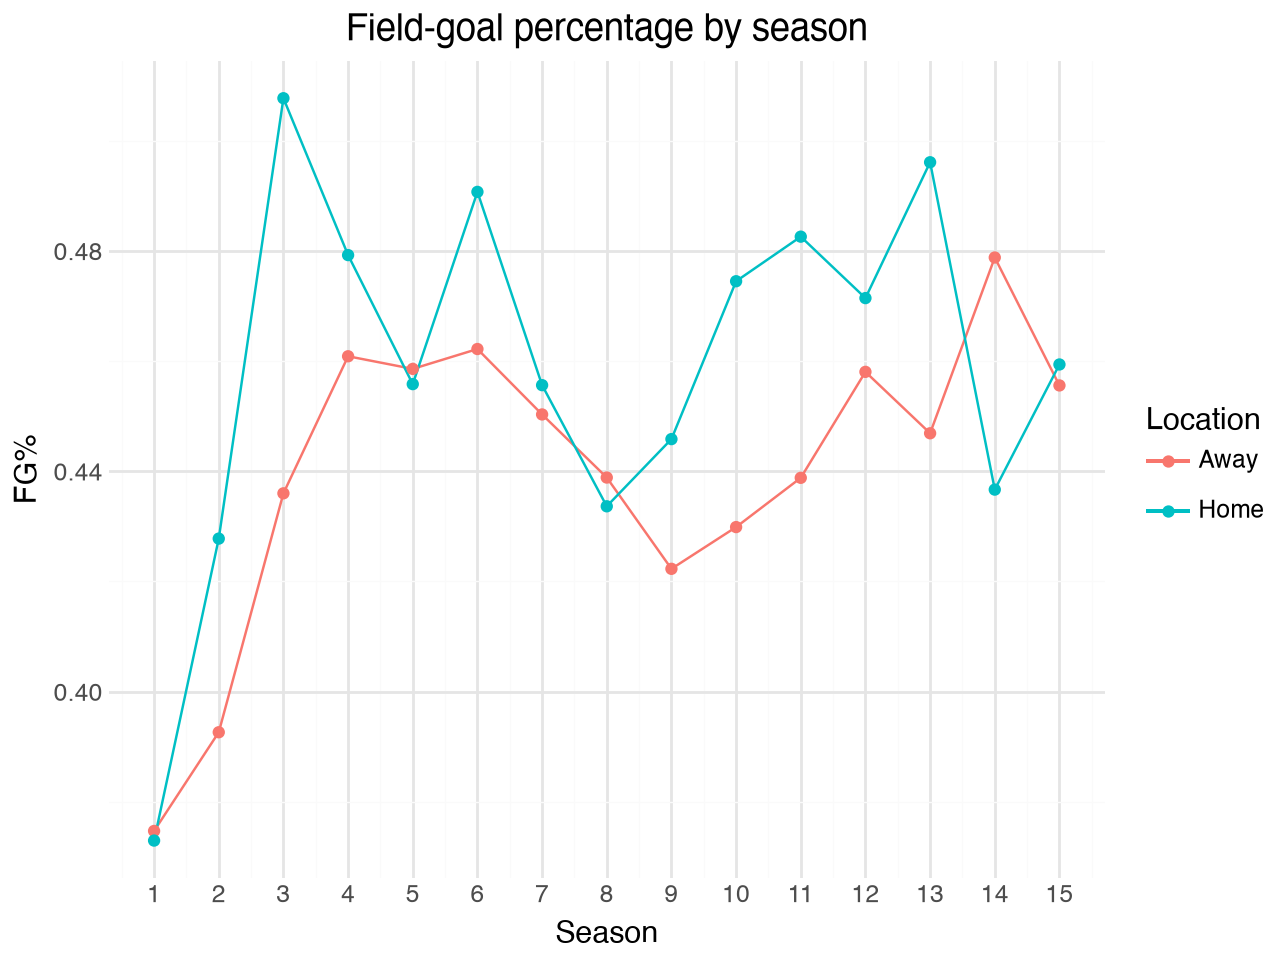

In [35]:
fg_by_season = kobe.groupby(["season", "location"])["fg_pct"].mean().reset_index()

(ggplot(fg_by_season, aes(x = "season", y = "fg_pct", color = "location"))
 + geom_line()
 + geom_point()
 + scale_x_continuous(breaks = range(1, 16))
 + labs(title = "Field-goal percentage by season", x = "Season", y = "FG%", color = "Location")
 + theme_minimal()
)


**PA 5.** Recreate this plot from its *grammar* description only:

- data: `kobe`; x = `rebounds`, fill = `location`
- geometry: density with `alpha = 0.4`
- one panel per `outcome`
- title "Rebounds per game", theme `theme_bw()`


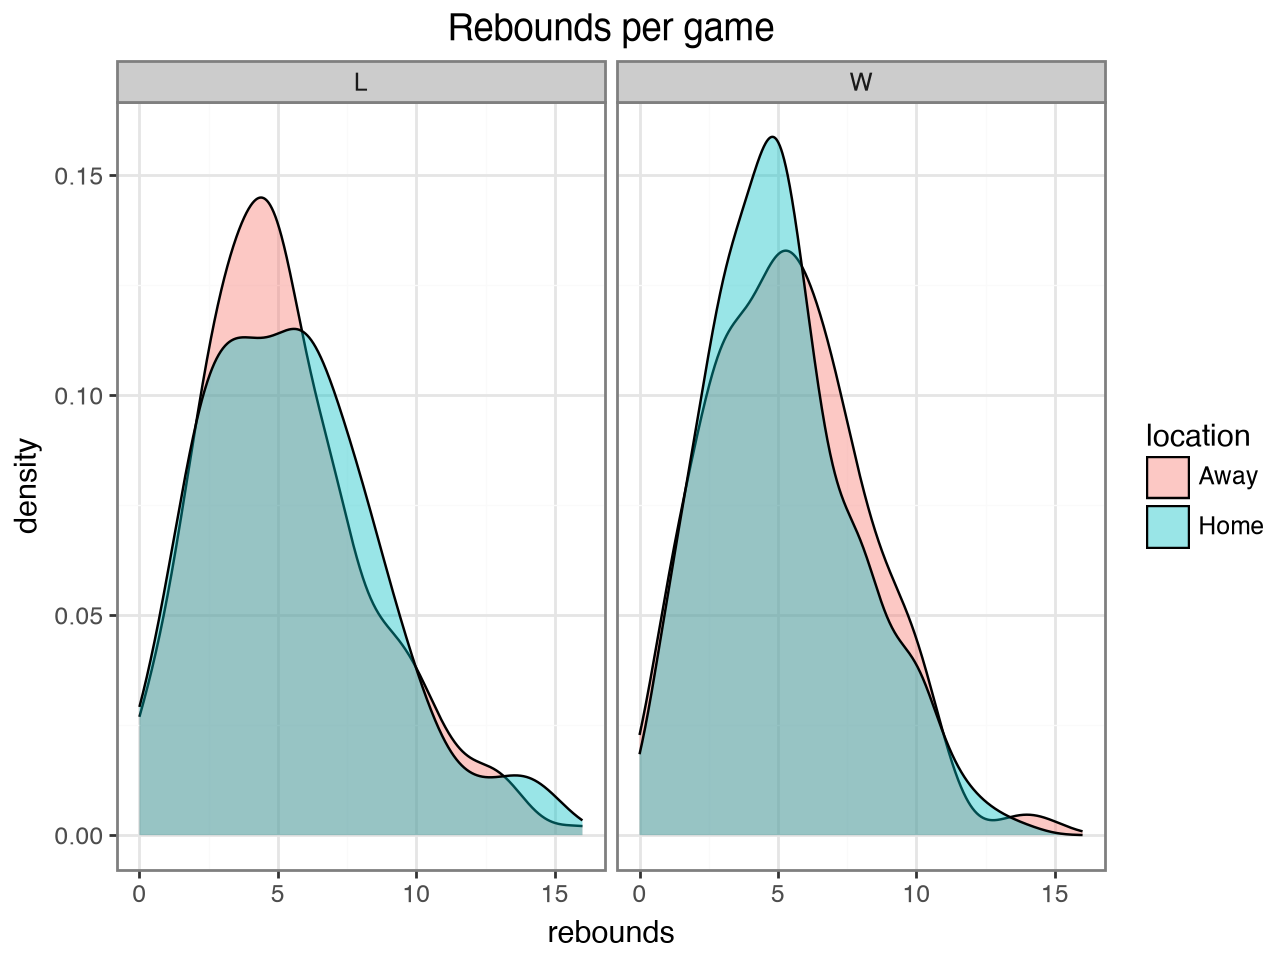

In [36]:
(ggplot(kobe, aes(x = "rebounds", fill = "location"))
 + geom_density(alpha = 0.4)
 + facet_wrap("outcome")
 + labs(title = "Rebounds per game")
 + theme_bw()
)


**PA 6 (write, don't code).** A classmate makes a scatterplot with `x = "season_label"` and `y = "points"` — one dot per game — and says it shows the career trend. Name two reasons a boxplot or a summarized line plot answers that question better.


**Answer:** (1) 82 dots per season stack into a vertical stripe, so the *distribution* within a season is invisible (over-plotting); (2) the eye can't average 82 dots — a boxplot shows the median directly and a line of season means shows the trend directly. Variable type (categorical x) + question ("how does the *typical* value change") → boxplot or summarized line.


---
## Summary

| Question | Variable types | Tool |
|---|---|---|
| What happens when I load a package? | — | `import pandas as pd`, `from plotnine import *` |
| How do I describe a plot? | — | `ggplot(data, aes(...)) + geom_*()` |
| Column → visual element, or a constant? | — | inside `aes(fill="col")` vs. outside `geom_bar(fill="purple")` |
| How many in each group? | 1 categorical | `geom_bar()` |
| …split by a second group? | 2 categorical | `aes(fill=)` + `position = "stack" / "dodge" / "fill"` |
| What shape is this variable? | 1 quantitative | `geom_histogram(bins=)`, `geom_density(alpha=)` |
| How does it differ across groups? | quantitative × categorical | `geom_boxplot()` |
| Are two variables related? | 2 quantitative | `geom_point()`, `geom_jitter()` |
| How does it change over time? | quantitative over order | summarize, then `geom_line()` + `geom_point()` |
| Make it presentable? | — | `labs()`, `scale_*()`, `theme_*()`, `theme(...)` |
| Does the pattern hold in every group? | + 1 categorical | `facet_wrap("col")`, `facet_grid("row ~ col")` |
